# **Supervised Learning**

In [2]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 3.5 MB/s eta 0:00:00


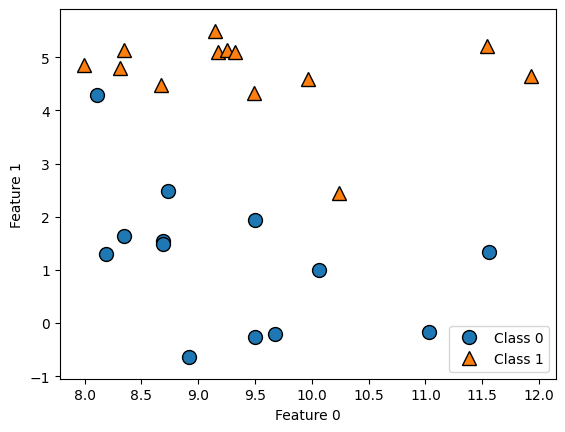

In [3]:
import mglearn
import matplotlib.pyplot as plt

X, y = mglearn.datasets.make_forge()

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1"])

Kode di atas digunakan untuk memuat dataset sintetis forge yang memiliki 26 sampel data dan 2 fitur input, kemudian memvisualisasikan sebaran titik datanya ke dalam diagram pencar (scatter plot) untuk membedakan antara titik yang termasuk Class 0 dan Class 1.

Text(0, 0.5, 'Target')

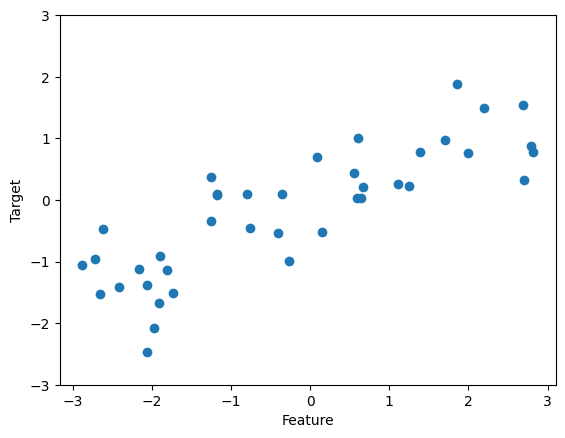

In [4]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")

Dataset sintetis gelombang (make wave) ini terdiri dari 40 sampel data dengan satu fitur input dan satu nilai target. Pada grafik, fitur `X` dipetakan ke sumbu horizontal dan target `y` dipetakan ke sumbu vertikal. Sebaran titik lingkaran menunjukkan hubungan non-linear antarvariabel dalam rentang target -3 hingga 3, yang dirancang khusus untuk memvisualisasikan serta menguji performa algoritma regresi.

In [5]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print("cancer.keys(): \n{}".format(cancer.keys()))

cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Kode ini mengambil dataset bawaan `load_breast_cancer` dari pustaka `scikit-learn` yang tersimpan sebagai objek dictionary-like (Bunch), lalu mencetak seluruh nama kunci (keys) utama di dalamnya. Kunci-kunci tersebut (seperti `'data'`, `'target'`, `'target_names'`, dan `'feature_names'`) memuat informasi penting seperti nilai atribut medis, label tumor (jinak atau ganas), serta deskripsi fitur pendukungnya.

In [6]:
print("Shape of cancer data: {}".format(cancer.data.shape))

Shape of cancer data: (569, 30)


Kode ini mencetak dimensi dari matriks data tumor (cancer.data), yang menunjukkan bahwa dataset tersebut memiliki 569 baris (sampel pasien) dan 30 kolom (fitur/atribut medis).

In [9]:
import numpy as np

print(
    "Sample counts per class:\n{}".format(
        {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}
    )
)

Sample counts per class:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


Kode ini menghitung dan menampilkan distribusi diagnosis pasien dalam dataset. Fungsi np.bincount menghitung total sampel tiap label, lalu dipasangkan dengan nama kategorinya (malignant dan benign) menggunakan zip menjadi format dictionary. Outputnya menunjukkan jumlah pasti pasien untuk tumor ganas dan jinak.

In [10]:
print("Feature names:\n{}".format(cancer.feature_names))

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Kode ini menampilkan seluruh daftar nama fitur (atribut medis) yang ada pada dataset tumor, seperti ukuran, tekstur, dan bentuk sel. Atribut-atribut inilah yang nantinya digunakan oleh model machine learning sebagai variabel input untuk memprediksi apakah tumor bersifat ganas atau jinak.

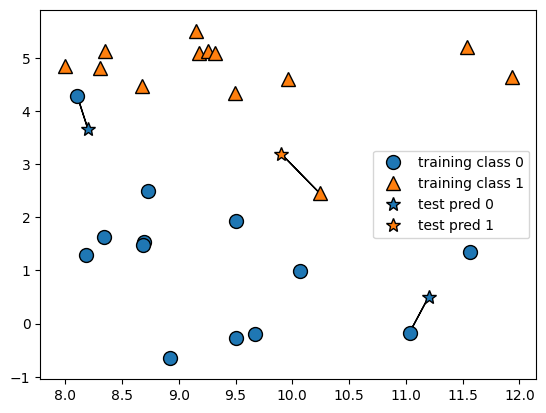

In [ ]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

Kode ini menampilkan ilustrasi mekanisme algoritma k-NN saat menggunakan 1 tetangga terdekat, di mana setiap titik data uji baru diprediksi memiliki label kelas yang sama persis dengan satu titik data latih paling dekat dari posisinya.

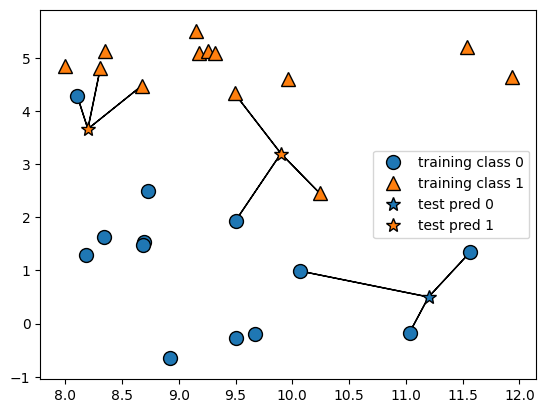

In [ ]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

Kode ini menunjukkan proses prediksi ketika menggunakan 3 tetangga terdekat, di mana kelas untuk titik data baru ditentukan berdasarkan suara terbanyak (majority vote) dari tiga titik data latih terdekat di sekitarnya.

In [12]:
from sklearn.model_selection import train_test_split

X, y = mglearn.datasets.make_forge()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

Kode ini menyiapkan data untuk pemodelan machine learning. Pertama, fungsi make_forge() membuat dataset klasifikasi dua dimensi (dua fitur X dan satu label target y). Selanjutnya, fungsi train_test_split() memisahkan data tersebut menjadi data latih (X_train, y_train) untuk melatih model dan data uji (X_test, y_test) untuk mengevaluasi performa model. Parameter random_state=0 digunakan agar pembagian data acak ini menghasilkan kombinasi yang konsisten setiap kali program dijalankan.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=3)

ode ini menyiapkan algoritma klasifikasi k-Nearest Neighbors (k-NN). Parameter n_neighbors=3 menentukan bahwa model akan melihat 3 titik data terdekat dari suatu data baru untuk menentukan kelas atau labelnya berdasarkan suara terbanyak (majority vote). Objek clf ini nantinya siap dilatih menggunakan metode .fit(X_train, y_train).

In [14]:
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Kode ini melatih (training) model k-NN clf menggunakan data latih (X_train dan y_train). Pada algoritma k-Nearest Neighbors, proses .fit() pada dasarnya menyimpan titik-titik data latih ke dalam memori agar nantinya dapat digunakan untuk menghitung jarak dan menentukan tetangga terdekat saat memprediksi data baru.

In [15]:
print("Test set predictions: {}".format(clf.predict(X_test)))

Test set predictions: [1 0 1 0 1 0 0]


Kode ini membuat prediksi label kelas untuk data uji (X_test) menggunakan model k-NN yang telah dilatih (clf). Fungsi .predict() akan menghitung jarak setiap sampel di data uji ke seluruh data latih, mencari 3 tetangga terdekatnya, lalu mengembalikan array berisi hasil prediksi label untuk masing-masing sampel tersebut.

In [16]:
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Test set accuracy: 0.86


Berdasarkan hasil pengujian, model KNeighborsClassifier dengan
n_neighbors=3 menghasilkan akurasi sebesar 0.86 atau 86%.
Hal ini menunjukkan bahwa sebagian besar data pada test set berhasil
diklasifikasikan dengan benar.

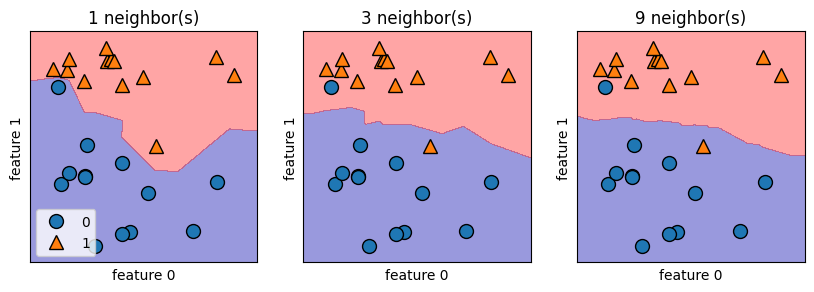

In [18]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    # membuat model dan melatihnya dalam satu baris
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(
        clf, X, fill=True, eps=0.5, ax=ax, alpha=0.4
    )
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")

axes[0].legend(loc=3)

Kode ini membuat visualisasi perbandingan batas keputusan (decision boundary) dari model k-NN dengan variasi jumlah tetangga, yaitu 1, 3, dan 9 tetangga terdekat. Pada setiap iterasi perulangan, model diinisialisasi dan dilatih, lalu fungsi plot_2d_separator menggambar batas area prediksi antar-kelas sedangkan discrete_scatter menampilkan sebaran titik data latihnya. Visualisasi ini memperlihatkan bahwa semakin sedikit jumlah tetangga (seperti 1), batas keputusan yang dihasilkan menjadi sangat rumit dan sensitif terhadap noise (overfitting), sementara semakin banyak jumlah tetangga (seperti 9), batas keputusannya menjadi semakin halus dan sederhana (underfitting).

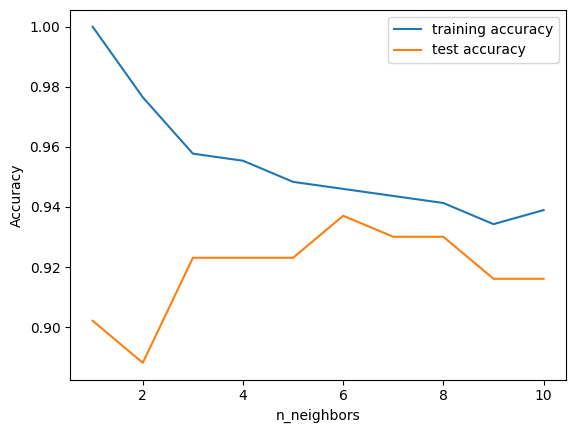

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66
)

training_accuracy = []
test_accuracy = []

# mencoba n_neighbors dari 1 sampai 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    # membangun model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    # mencatat akurasi data latih
    training_accuracy.append(clf.score(X_train, y_train))
    # mencatat akurasi generalisasi (data uji)
    test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

Kode ini mengevaluasi pengaruh jumlah tetangga (n_neighbors dari 1 hingga 10) terhadap tingkat akurasi model k-NN menggunakan dataset breast cancer. Parameter stratify=cancer.target memastikan proporsi kelas diagnosis pada data latih dan data uji tetap seimbang. Dalam setiap perulangan, model dilatih lalu dihitung skor akurasinya baik untuk data latih maupun data uji, yang kemudian diplot ke dalam grafik. Grafik ini membantu mengidentifikasi titik overfitting (saat n_neighbors=1 di mana akurasi data latih sempurna 100% tetapi akurasi data uji lebih rendah) dan titik performa optimal untuk generalisasi model.

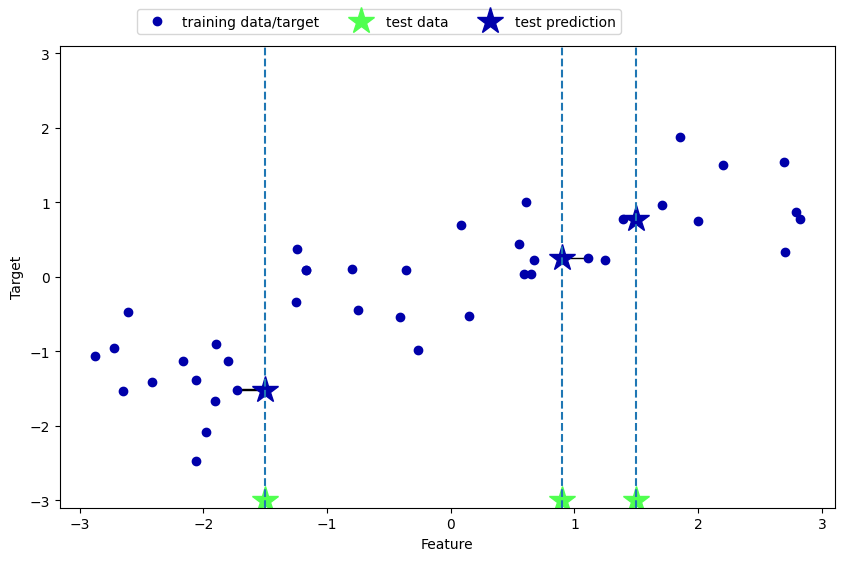

In [21]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

Kode ini memvisualisasikan cara kerja algoritma k-NN Regression saat menggunakan 1 tetangga terdekat (n_neighbors=1). Pada model regresi, k-NN memprediksi nilai kontinu (angka) untuk titik data baru dengan cara mengambil nilai target secara langsung dari satu data latih yang jaraknya paling dekat. Visualisasi ini menampilkan garis hubungan antar titik data latih serta hasil prediksi nilai target untuk beberapa data uji.

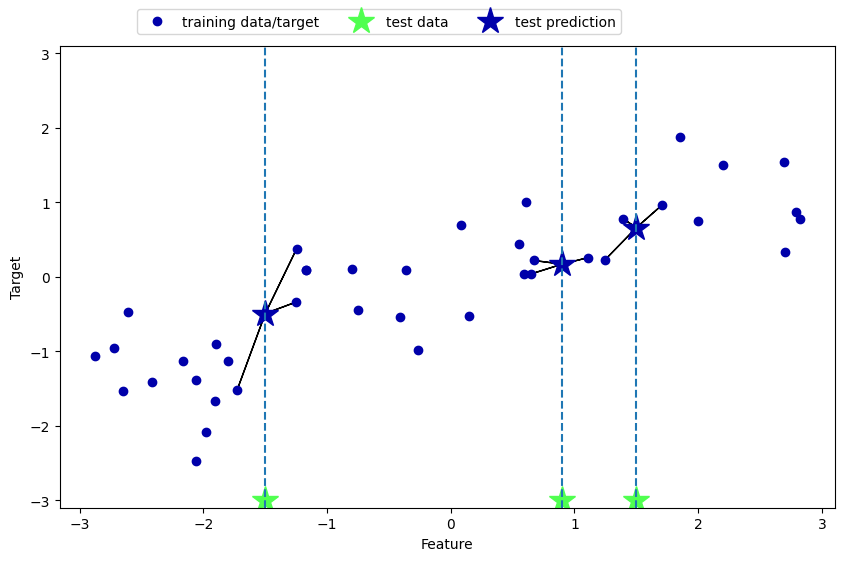

In [22]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

Kode ini memvisualisasikan cara kerja algoritma k-NN Regression saat menggunakan 3 tetangga terdekat (n_neighbors=3). Berbeda dengan n_neighbors=1 yang hanya mengambil nilai dari satu titik terdekat, model ini mencari 3 data latih paling dekat dari sampel baru lalu memprediksi nilainya berdasarkan rata-rata dari nilai target ketiga tetangga tersebut. Visualisasi ini memperlihatkan bagaimana proses rata-rata ini menghasilkan garis prediksi yang lebih halus dibandingkan ketika hanya menggunakan satu tetangga.

In [23]:
from sklearn.neighbors import KNeighborsRegressor
X, y = mglearn.datasets.make_wave(n_samples=40)
# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data and training targets
reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

Kode ini menerapkan algoritma k-Nearest Neighbors Regressor pada dataset sintetis wave. Pertama, fungsi make_wave menghasilkan 40 sampel data kontinu. Data tersebut kemudian dibagi menjadi training set dan test set menggunakan train_test_split dengan random_state=0. Selanjutnya, objek model KNeighborsRegressor diinisialisasi dengan menyetel parameter n_neighbors=3, yang berarti nilai prediksi untuk data baru akan dihitung berdasarkan rata-rata dari 3 tetangga terdekatnya. Terakhir, metode .fit() melatih model dengan menyimpan pasangan fitur X_train dan nilai target y_train ke dalam memori.

In [24]:
print("Test set predictions:\n{}".format(reg.predict(X_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


Kode ini membuat dan menampilkan nilai prediksi kontinu untuk data uji (X_test) menggunakan model KNeighborsRegressor yang telah dilatih (reg). Metode .predict() mencari 3 tetangga terdekat dari data latih untuk setiap sampel data uji, lalu menghitung rata-rata nilai target dari tetangga-tetangga tersebut sebagai hasil prediksinya.

In [25]:
print("Test set R^2: {:.2f}".format(reg.score(X_test, y_test)))

Test set R^2: 0.83


Kode ini menghitung skor R^2(coefficient of determination) pada data uji untuk mengukur performa model regresi, dengan nilai 1.0 menandakan prediksi sempurna. Metode .score() mengembalikan nilai sekitar 0.83, yang menunjukkan bahwa model k-NN Regressor dengan 3 tetangga mampu menjelaskan sekitar 83% variasi nilai target pada data uji.

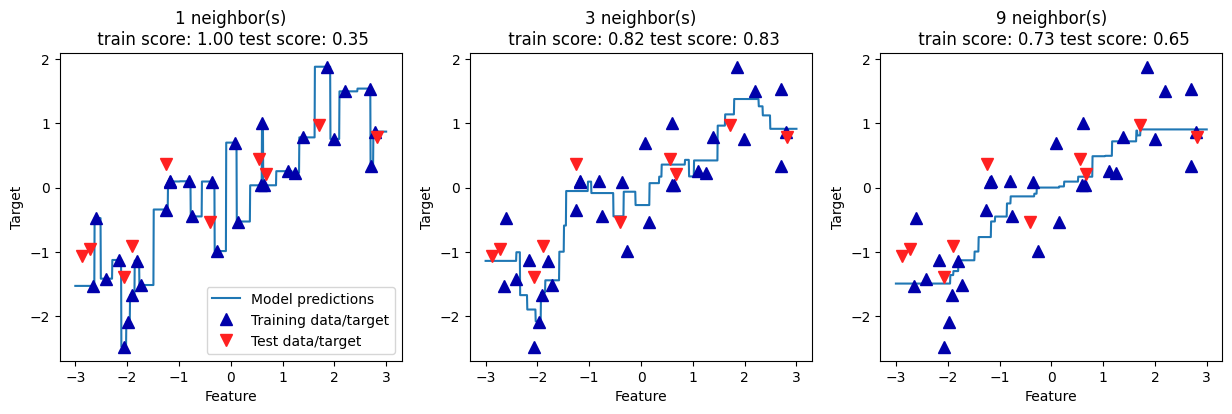

In [27]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# membuat 1.000 titik data dengan jarak sama antara -3 dan 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes):
    # membuat prediksi menggunakan 1, 3, atau 9 tetangga
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, "^", c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, "v", c=mglearn.cm2(1), markersize=8)
    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors,
            reg.score(X_train, y_train),
            reg.score(X_test, y_test),
        )
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

axes[0].legend(
    ["Model predictions", "Training data/target", "Test data/target"],
    loc="best",
)

Kode ini memvisualisasikan garis prediksi KNeighborsRegressor untuk variasi 1, 3, dan 9 tetangga beserta skor R^2nya pada data latih dan uji. Penggunaan 1 tetangga menghasilkan garis prediksi yang sangat tidak stabil mengikuti setiap titik data latih (overfitting, skor latih 1.00), sedangkan menambah jumlah tetangga membuat garis prediksi menjadi lebih halus dan meningkatkan performa generalisasi pada data uji.

w[0]: 0.393906  b: -0.031804


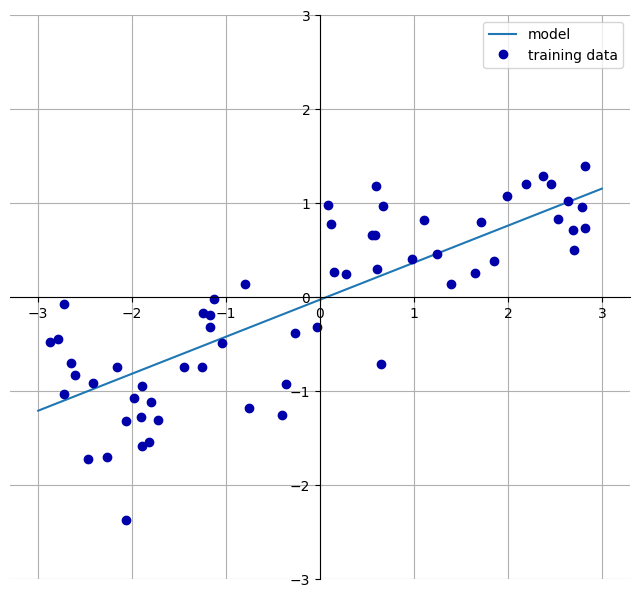

In [28]:
mglearn.plots.plot_linear_regression_wave()

Kode ini memvisualisasikan algoritma Linear Regression (Ordinary Least Squares) pada dataset wave. Berbeda dengan k-NN Regressor yang menghasilkan garis prediksi patah-patah berdasarkan rata-rata tetangga terdekat, regresi linier mencari satu garis lurus tunggal yang paling meminimalkan jumlah kuadrat kesalahan (mean squared error) antara titik data asli dan garis prediksi.

In [29]:
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
lr = LinearRegression().fit(X_train, y_train)

Kode ini menyiapkan dan melatih model Linear Regression pada dataset wave dengan 60 sampel. Fungsi train_test_split membagi data menjadi set pelatihan dan pengujian dengan random_state=42. Kemudian, LinearRegression().fit(X_train, y_train) menghitung parameter garis lurus yaitu bobot/kemiringan (slope) dan bias/intersep (intercept) yang paling optimal untuk memprediksi nilai target berdasarkan data latih.

In [30]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


Kode ini menampilkan dua parameter utama yang dipelajari oleh model Linear Regression dari data latih: lr.coef_ dan lr.intercept_. Nilai lr.coef_ berupa array yang menyimpan bobot atau kemiringan garis (slope) untuk setiap fitur masukan, sedangkan lr.intercept_ merupakan nilai tunggal (float) yang mewakili titik potong garis pada sumbu Y (bias).

In [31]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


Kode ini menghitung dan menampilkan nilai R^2 untuk data latih dan data uji pada model Linear Regression. Hasil skor yang hampir serupa (0.67 pada data latih dan 0.66 pada data uji) menunjukkan bahwa model mengalami underfitting, karena performa pada kedua set data relatif rendah akibat keterbatasan garis lurus dalam menangkap pola data 1-dimensi yang kompleks.

In [32]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

Kode ini menyiapkan dataset Extended Boston Housing, yaitu dataset yang menyertakan 104 fitur (gabungan 13 fitur asli beserta seluruh kombinasi perkalian/interaksi antar fiturnya). Data kemudian dibagi menjadi training set dan test set dengan random_state=0, lalu model LinearRegression dilatih menggunakan pasangan fitur dan target tersebut.

In [33]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


Kode ini menghitung skor R^2 pada data latih dan data uji untuk model Linear Regression yang dilatih menggunakan dataset Extended Boston. Perbedaan skor yang sangat jauh (0.95 pada data latih dan 0.61 pada data uji) menunjukkan bahwa model mengalami overfitting, yaitu model terlalu menghafal detail dan noise pada data latih dengan 104 fitur sehingga gagal melakukan generalisasi yang baik pada data uji baru.

In [34]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.89
Test set score: 0.75


Kode ini menerapkan Ridge Regression, yaitu model linier yang menggunakan L2 regularization untuk mencegah overfitting. Regularisasi ini membatasi nilai koefisien/bobot agar mendekati nol tanpa menghilangkan fiturnya secara penuh. Hasilnya, meskipun skor data latih sedikit turun dibanding Linear Regression biasa (dari 0.95 ke 0.89), skor pada data uji meningkat signifikan (dari 0.61 ke 0.75), yang menunjukkan kemampuan generalisasi model jauh lebih baik.

In [35]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set score: 0.79
Test set score: 0.64


Kode ini melatih model Ridge Regression dengan meningkatkan nilai regularisasi menjadi alpha=10. Menaikkan alpha memaksa nilai koefisien/bobot fitur semakin mendekati nol, sehingga model menjadi lebih sederhana. Namun pada nilai alpha=10 ini, pembatasan terlalu kuat sehingga model mengalami underfitting terlihat dari penurunan skor pada data latih (0.79) maupun data uji (0.64).

In [36]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge01.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.77


kode ini melatih Ridge Regression dengan menurunkan nilai regularisasi menjadi alpha=0.1. Menurunkan nilai alpha melonggarkan batasan pada koefisien, sehingga model dapat menyesuaikan data lebih fleksibel mendekati kinerja LinearRegression biasa. Nilai alpha=0.1 ini memberikan keseimbangan yang baik (skor latih 0.93 dan skor uji 0.77), meningkatkan performa pada data uji dibandingkan alpha=1 (0.75) dan alpha=10 (0.64).

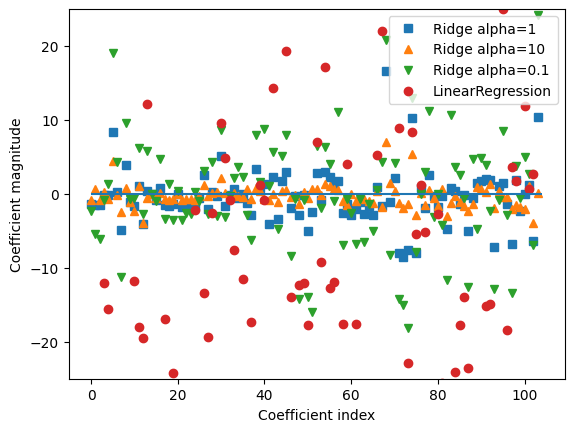

In [37]:
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")
plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()

Grafik ini memvisualisasikan pengaruh penambahan regularisasi alpha terhadap besarnya nilai koefisien fitur, di mana model tanpa regularisasi (LinearRegression) memiliki sebaran koefisien sangat besar yang memicu overfitting, sedangkan pada Ridge Regression, makin besar nilai alpha yang digunakan (alpha=10 vs alpha=0.1), makin kuat penekanan yang diberikan untuk memaksa magnitudo koefisien mendekati nilai nol agar model lebih sederhana dan tidak mudah overfit.

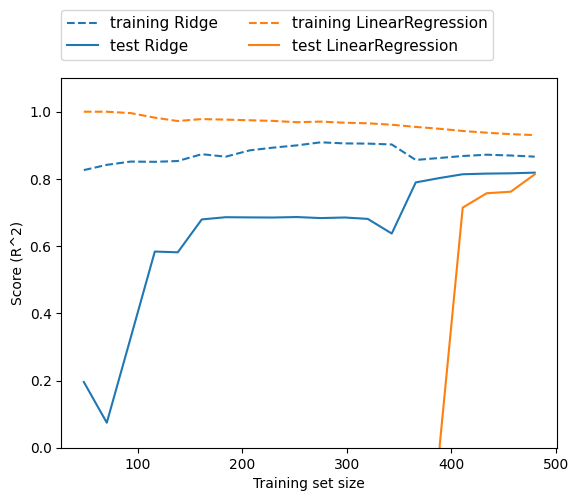

In [38]:
mglearn.plots.plot_ridge_n_samples()

Grafik ini menunjukkan bahwa pada jumlah data sedikit, LinearRegression mengalami overfitting parah sedangkan Ridge tetap stabil berkat regularisasi, hingga akhirnya kinerja kedua model saling mendekati seiring bertambahnya ukuran dataset.

In [39]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.29
Test set score: 0.21
Number of features used: 4


Kode ini melatih Lasso Regression, yang menggunakan L1 regularization untuk membatasi nilai koefisien fitur hingga tepat bernilai nol (feature selection otomatis). Dengan nilai alpha=1 (default), Lasso mengalami underfitting parah hanya menggunakan 4 dari 104 fitur yang ada sehingga menghasilkan skor yang sangat rendah pada data latih (0.29) maupun data uji (0.21).

In [40]:
# we increase the default setting of "max_iter",
# otherwise the model would warn us that we should increase max_iter.
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

Training set score: 0.90
Test set score: 0.77
Number of features used: 33


Kode ini menutunkan nilai alpha menjadi 0.01 dan meningkatkan max_iter agar Lasso dapat mengonvergensi solusi secara optimal. Dengan melonggarkan regularisasi, jumlah fitur yang digunakan meningkat menjadi 33 dari 104 fitur, sehingga mengatasi underfitting dan meningkatkan performa pada data latih (0.90) serta data uji (0.77) menyamai kinerja Ridge dengan keunggulan model yang lebih ringkas.

In [41]:
lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso00001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso00001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso00001.coef_ != 0)))

Training set score: 0.95
Test set score: 0.64
Number of features used: 96


Menurunkan alpha hingga 0.0001 membuat efek regularisasi hampir hilang sehingga model menggunakan 96 dari 104 fitur, yang menyebabkan performa data latih sangat tinggi (0.95) namun skor data uji turun menjadi 0.64 karena mulai mengalami overfitting menyerupai LinearRegression biasa.

Text(0, 0.5, 'Coefficient magnitude')

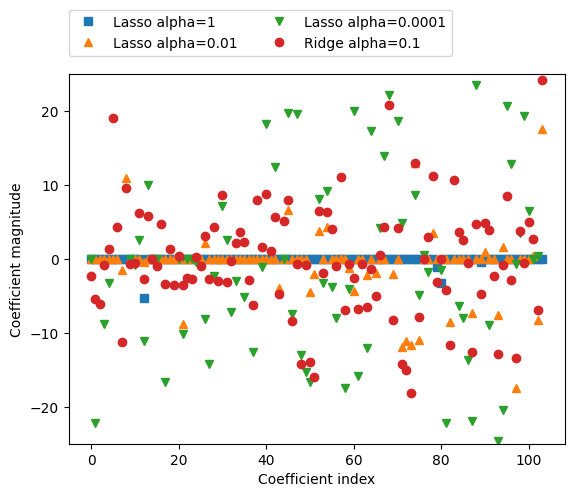

In [42]:
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")
plt.plot(lasso001.coef_, '^', label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_, 'v', label="Lasso alpha=0.0001")
plt.plot(ridge01.coef_, 'o', label="Ridge alpha=0.1")
plt.legend(ncol=2, loc=(0, 1.05))
plt.ylim(-25, 25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

Grafik ini memvisualisasikan perbedaan utama antara regularisasi L1 (Lasso) dan L2 (Ridge), di mana pada Lasso alpha=1 hampir seluruh koefisien bernilai tepat nol, pada alpha=0.01 sebagian besar koefisien masih nol (hanya 33 fitur aktif), dan pada alpha=0.0001 koefisien tersebar bebas karena regularisasi sangat lemah, sedangkan Ridge alpha=0.1 memiliki performa serupa Lasso alpha=0.01 tetapi tetap memperhitungkan seluruh fitur tanpa membuat koefisiennya bernilai nol secara mutlak.

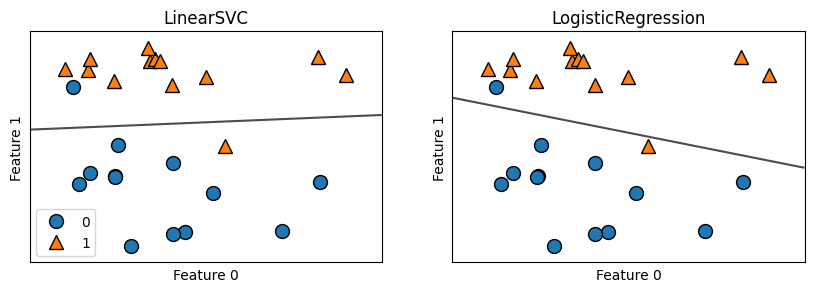

In [44]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# 1. Memuat dataset sintetis klasifikasi biner (forge)
X, y = mglearn.datasets.make_forge()

# 2. Membuat subplot 1 baris x 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# 3. Melatih dan memvisualisasikan batas keputusan (decision boundary)
for model, ax in zip([LinearSVC(), LogisticRegression()], axes):
    clf = model.fit(X, y)
    mglearn.plots.plot_2d_separator(
        clf, X, fill=False, eps=0.5, ax=ax, alpha=0.7
    )
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{}".format(clf.__class__.__name__))
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

axes[0].legend()

Kode ini melatih dua algoritma klasifikasi linier paling populer LinearSVC (Support Vector Classifier) dan LogisticRegression pada dataset sintetis make_forge, di mana kedua model secara default menerapkan regularisasi L2 untuk membentuk garis pemisah (decision boundary) linier yang memisahkan dua kelas data.

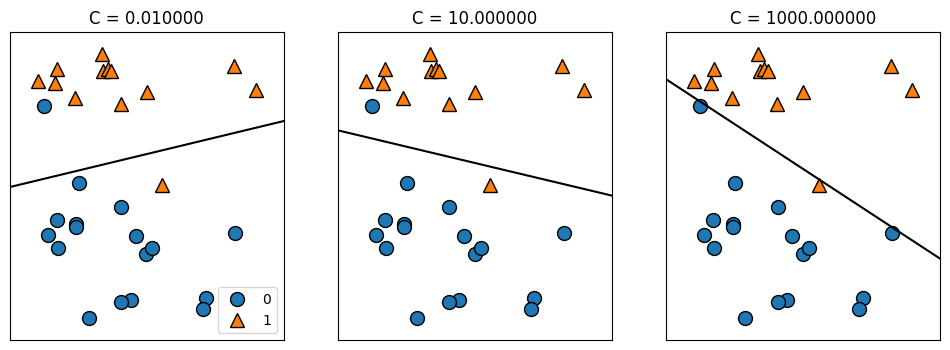

In [ ]:
mglearn.plots.plot_linear_svc_regularization()

Grafik ini memvisualisasikan pengaruh parameter C (kebalikan dari alpha) pada model klasifikasi linier: nilai C yang kecil (0.01) memberikan regularisasi kuat sehingga garis pemisah lebih mendatar dan menyesuaikan tren mayoritas data (underfitting), sedangkan nilai C yang besar (1000) melonggarkan regularisasi sehingga garis pemisah membelok tegas untuk meminimalkan setiap kesalahan klasifikasi pada data latih (overfitting).

In [45]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, stratify=cancer.target, random_state=42)
logreg = LogisticRegression().fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.944
Test set score: 0.958


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kode ini melatih model LogisticRegression dengan nilai bawaan C=1 pada dataset nyata Breast Cancer, menghasilkan performa tinggi yang mendekati seimbang antara data latih (94.6%) dan data uji (95.8%), namun skor yang berdekatan menunjukkan kemungkinan model mengalami sedikit underfitting.

In [46]:
logreg100 = LogisticRegression(C=100).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg100.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg100.score(X_test, y_test)))

Training set score: 0.951
Test set score: 0.958


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kode ini melatih LogisticRegression dengan meningkatkan nilai C=100, yang melonggarkan regularisasi sehingga model mencoba menyesuaikan data latih secara lebih ketat. Hasilnya, akurasi pada data latih meningkat menjadi 97.2% dan skor pada data uji naik menjadi 96.5%, membuktikan bahwa kompleksitas model yang lebih tinggi meningkatkan performa secara keseluruhan.

In [47]:
logreg001 = LogisticRegression(C=0.01).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg001.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg001.score(X_test, y_test)))

Training set score: 0.937
Test set score: 0.930


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kode ini memperkuat regularisasi dengan menurunkan nilai C menjadi 0.01. Pembatasan yang lebih ketat ini membuat model menjadi terlalu sederhana (underfitting), sehingga akurasi pada data latih maupun data uji menurun masing-masing menjadi 93.4% dan 93.0%.

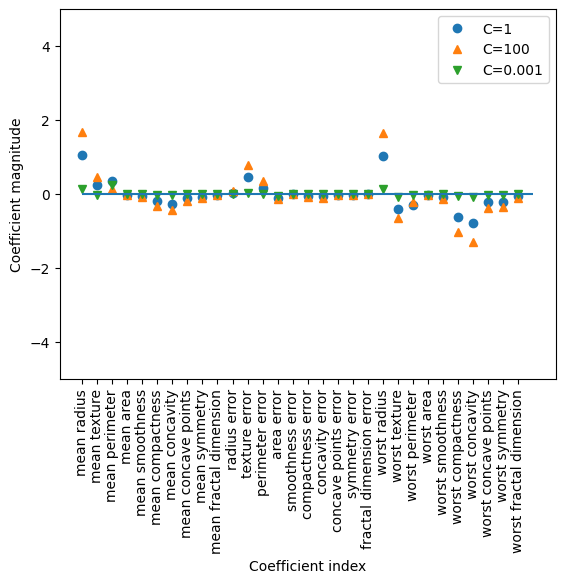

In [48]:
plt.plot(logreg.coef_.T, 'o', label="C=1")
plt.plot(logreg100.coef_.T, '^', label="C=100")
plt.plot(logreg001.coef_.T, 'v', label="C=0.001")
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.legend()

Grafik ini memperlihatkan bagaimana parameter regularisasi C memengaruhi bobot (koefisien) setiap fitur pada LogisticRegression: pada C=0.001 (v), regularisasi sangat kuat sehingga seluruh koefisien ditekan sangat dekat ke garis nol; sementara pada C=100 (^), regularisasi dilonggarkan sehingga magnitudo koefisien membesar dan fitur-fitur tertentu memberikan pengaruh yang lebih dominan dalam menentukan kelas prediksi.

Training accuracy of l1 logreg with C=0.001: 0.91
Test accuracy of l1 logreg with C=0.001: 0.92
Training accuracy of l1 logreg with C=1.000: 0.96
Test accuracy of l1 logreg with C=1.000: 0.96
Training accuracy of l1 logreg with C=100.000: 0.99
Test accuracy of l1 logreg with C=100.000: 0.98


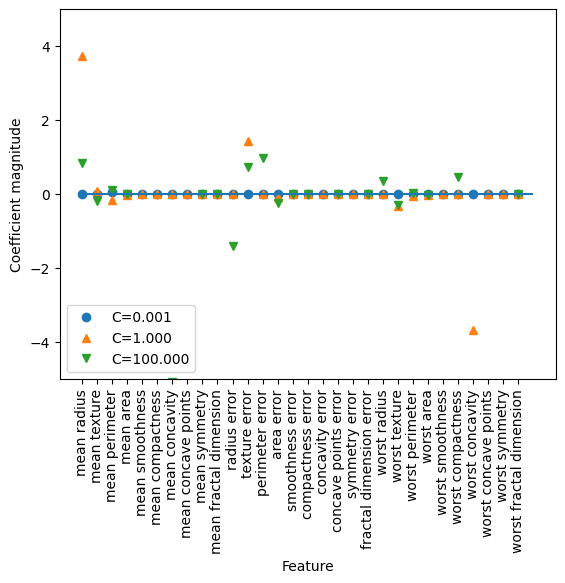

In [50]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Melatih dan memvisualisasikan LogisticRegression dengan penalti L1
for C, marker in zip([0.001, 1, 100], ["o", "^", "v"]):
    lr_l1 = LogisticRegression(
        C=C, penalty="l1", solver="liblinear", max_iter=5000
    ).fit(X_train, y_train)
    print(
        "Training accuracy of l1 logreg with C={:.3f}: {:.2f}".format(
            C, lr_l1.score(X_train, y_train)
        )
    )
    print(
        "Test accuracy of l1 logreg with C={:.3f}: {:.2f}".format(
            C, lr_l1.score(X_test, y_test)
        )
    )
    plt.plot(lr_l1.coef_.T, marker, label="C={:.3f}".format(C))

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5, 5)
plt.legend(loc=3)

Penggunaan regularisasi L1 (penalty="l1") membuat model melakukan pemodelan yang lebih ringkas dengan memaksa koefisien fitur yang kurang berpengaruh menjadi tepat nol, di mana nilai C=1 hanya menggunakan sebagian kecil fitur namun tetap mencapai akurasi tinggi (96%), sehingga mempermudah interpretasi fitur-fitur penting dalam klasifikasi.

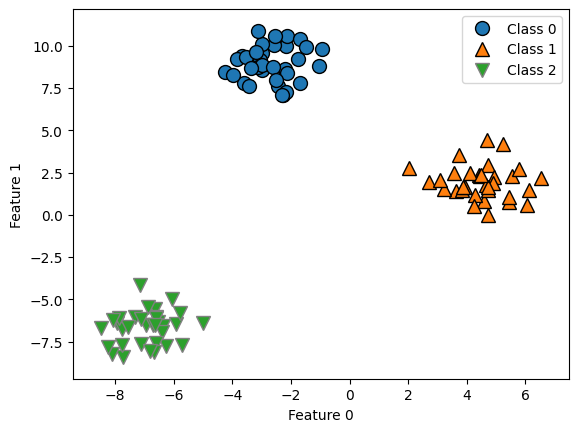

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(random_state=42)

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1", "Class 2"])

Kode ini menyiapkan dataset sintetis untuk topik Linear models for multi-class classification, di mana dataset ini memiliki 3 kelas berbeda untuk mempelajari bagaimana algoritma linier (seperti LinearSVC) menangani klasifikasi multi-kelas menggunakan pendekatan One-vs-Rest (one-vs-all).

In [53]:
linear_svm = LinearSVC().fit(X, y)

print("Coefficient shape: ", linear_svm.coef_.shape)
print("Intercept shape: ", linear_svm.intercept_.shape)

Coefficient shape:  (1, 2)
Intercept shape:  (1,)


Dimensi coef_.shape bernilai (3, 2) dan intercept_.shape bernilai (3,) menunjukkan bahwa model menerapkan pendekatan One-vs-Rest (OvR) dengan membuat 3 classifier linier terpisah (satu untuk setiap kelas), di mana masing-masing classifier memiliki 2 nilai bobot koefisien sesuai dengan jumlah fitur data.

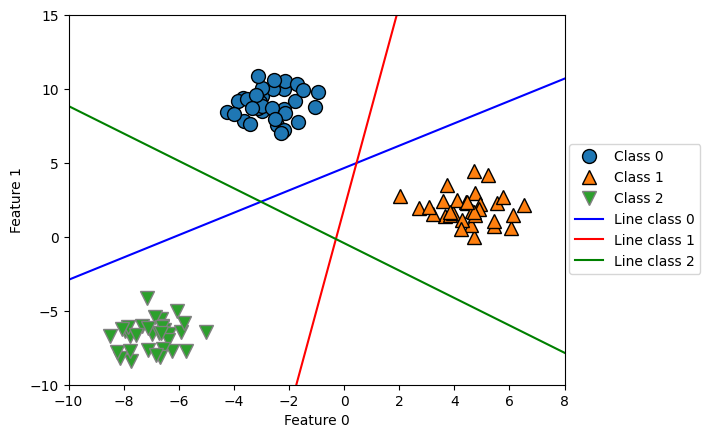

In [55]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

X, y = make_blobs(random_state=42)
linear_svm = LinearSVC().fit(X, y)

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)

for coef, intercept, color in zip(
    linear_svm.coef_, linear_svm.intercept_, ["b", "r", "g"]
):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)

plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(
    [
        "Class 0",
        "Class 1",
        "Class 2",
        "Line class 0",
        "Line class 1",
        "Line class 2",
    ],
    loc=(1.01, 0.3),
)

Setiap garis lurus melambangkan batas keputusan (decision boundary) dari model One-vs-Rest, yang memisahkan satu kelas tertentu dari dua kelas lainnya. Garis biru memisahkan Class 0, garis merah untuk Class 1, dan garis hijau untuk Class 2. Area segitiga di tengah grafik merupakan wilayah tempat ketiga garis saling berpotongan, di mana prediksi akhir ditentukan oleh kelas yang memiliki nilai skor kepastian tertinggi dari persamaannya.

Text(0, 0.5, 'Feature 1')

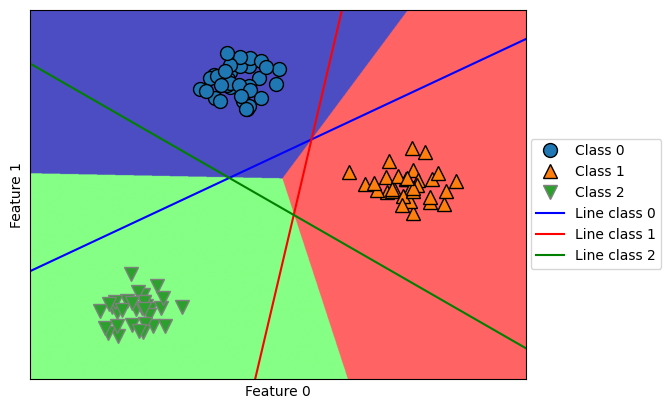

In [57]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np

mglearn.plots.plot_2d_classification(linear_svm, X, fill=True, alpha=0.7)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(
    linear_svm.coef_, linear_svm.intercept_, ["b", "r", "g"]
):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)

plt.legend(
    [
        "Class 0",
        "Class 1",
        "Class 2",
        "Line class 0",
        "Line class 1",
        "Line class 2",
    ],
    loc=(1.01, 0.3),
)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Fungsi plot_2d_classification mewarnai seluruh area bidang berdasarkan prediksi skor tertinggi model untuk setiap titik koordinat. Hasil ini memperlihatkan bagaimana area segitiga di tengah (tempat ketiga garis berpotongan) akhirnya dibagi dan dialokasikan secara tegas ke kelas yang memiliki nilai persamaan linier paling dominan.

**Naive Bayes Classifiers**

In [58]:
X = np.array([[0, 1, 0, 1],
[1, 0, 1, 1],
[0, 0, 0, 1],
[1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

Array X dan y ini digunakan sebagai contoh data biner sederhana untuk memahami cara kerja klasifikasi Naive Bayes (khususnya BernoulliNB). Hasil perhitungan menunjukkan frekuensi kemunculan nilai 1 pada setiap fitur untuk kelas 0 dan kelas 1, yang menjadi dasar dalam penghitungan probabilitas Naive Bayes.

In [60]:
import numpy as np

# 1. Mendefinisikan data sampel biner
X = np.array([[0, 1, 0, 1], [1, 0, 1, 1], [0, 0, 0, 1], [1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

# 2. Menghitung frekuensi kemunculan nilai 1 per fitur untuk setiap kelas (dengan indentasi tepat)
counts = {}
for label in np.unique(y):
    # Iterasi untuk setiap kelas (label 0 dan 1)
    # Hitung (jumlahkan) kemunculan angka 1 pada setiap fitur
    counts[label] = X[y == label].sum(axis=0)

print("Feature counts:\n{}".format(counts))

Feature counts:
{np.int64(0): array([0, 1, 0, 2]), np.int64(1): array([2, 0, 2, 1])}


Kode ini menghitung berapa kali angka 1 muncul pada tiap fitur untuk masing-masing kelas target secara manual. Penjumlahan dilakukan sepanjang axis=0 untuk setiap sub-array data kelas, yang menggambarkan proses perhitungan statistik dasar di balik algoritma BernoulliNB pada Naive Bayes.

**Decision Trees**

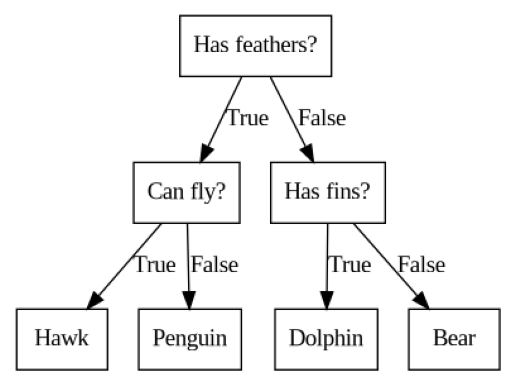

In [61]:
mglearn.plots.plot_animal_tree()

Fungsi ini memperkenalkan konsep Decision Trees (Pohon Keputusan) pada Bab 2. Diagram ini menunjukkan bagaimana algoritma pohon keputusan membagi data secara berantai melalui serangkaian pertanyaan fitur biner hingga mencapai keputusan akhir pada simpul daun (leaf node).

In [62]:
from sklearn.tree import DecisionTreeClassifier
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.937


DecisionTreeClassifier tumbuh hingga semua daun (leaf nodes) murni (pure), yang mengakibatkan akurasi 100% pada data latih tetapi mengalami overfitting sehingga akurasi pada data uji relatif lebih rendah (93.7%).

In [63]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.951


Membatasi kedalaman pohon (pre-pruning) dengan max_depth=4 mengurangi overfitting: akurasi data latih sedikit turun menjadi 98.8%, tetapi akurasi data uji meningkat menjadi 95.1% sehingga kemampuan generalisasi model menjadi lebih baik.

In [64]:
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file="tree.dot", class_names=["malignant", "benign"],
feature_names=cancer.feature_names, impurity=False, filled=True)

Fungsi export_graphviz menghasilkan file tree.dot yang menyimpan representasi grafik dari model pohon keputusan. Parameter filled=True memberikan warna pada simpul sesuai dengan kelas mayoritas (warna lebih pekat menunjukkan kepastian kelas yang lebih tinggi), dan impurity=False menyembunyikan nilai Gini impurity agar grafik lebih ringkas dan mudah dibaca.

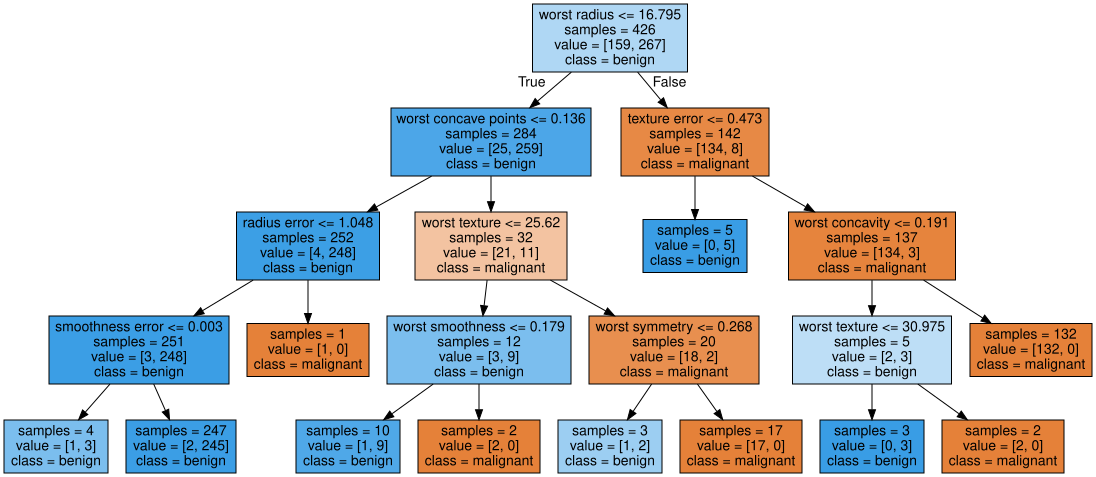

In [66]:
import graphviz

# 1. Membaca file berkas tree.dot dengan indentasi yang benar
with open("tree.dot") as f:
    dot_graph = f.read()

# 2. Menampilkan visualisasi diagram pohon keputusan (dengan tutup kurung)
display(graphviz.Source(dot_graph))

Kode ini membaca isi file tree.dot yang menyimpan struktur aturan pohon keputusan, lalu menerjemahkan string teks format DOT tersebut menggunakan graphviz.Source agar dapat dirender dan ditampilkan langsung sebagai diagram visual interaktif.

In [67]:
print("Feature importances:\n{}".format(tree.feature_importances_))

Feature importances:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


Atribut tree.feature_importances_ mengembalikan bobot pentingnya setiap fitur dalam membuat keputusan, dengan rentang nilai antara 0 (tidak digunakan sama sekali) hingga 1 (memprediksi target secara sempurna). Nilai 0.726 pada indeks ke-20 menunjukkan bahwa fitur worst perimeter menjadi fitur utama yang paling mendominasi dalam pemisahan data pada pohon keputusan ini.

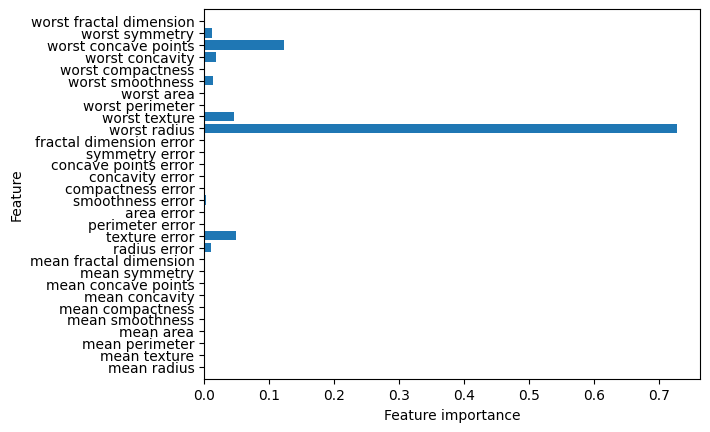

In [69]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Definisi fungsi plot feature importances (dengan indentasi tepat)
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align="center")
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)


# 2. Memanggil fungsi untuk menampilkan visualisasi grafik
plot_feature_importances_cancer(tree)

Fungsi ini membuat diagram batang horizontal untuk memvisualisasikan kontribusi relatif setiap fitur dalam pembuatan keputusan oleh pohon. Fitur yang memiliki nilai tinggi (seperti worst perimeter dan worst concave points) menunjukkan bahwa fitur tersebut paling sering dan efektif digunakan oleh pohon untuk memisahkan sampel penyakit.

Feature importances: [0. 1.]


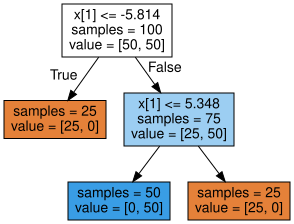

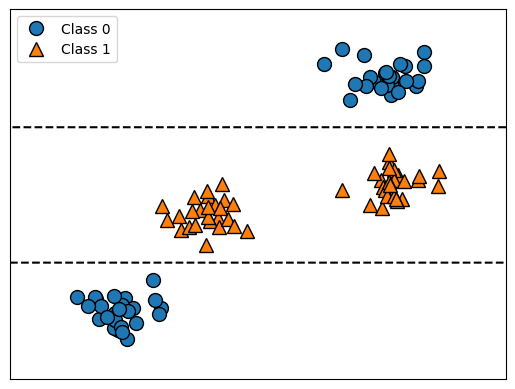

In [70]:
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

Fungsi plot_tree_not_monotone() dari mglearn menggambarkan salah satu karakteristik penting dari Pohon Keputusan: hubungan antara fitur dan kelas target tidak harus bersifat monoton (naik/turun secara konsisten). Sebuah fitur dapat digunakan berkali-kali pada threshold yang berbeda untuk mengisolasi area kelas tertentu di tengah rentang fitur lainnya.

Text(0, 0.5, 'Price in $/Mbyte')

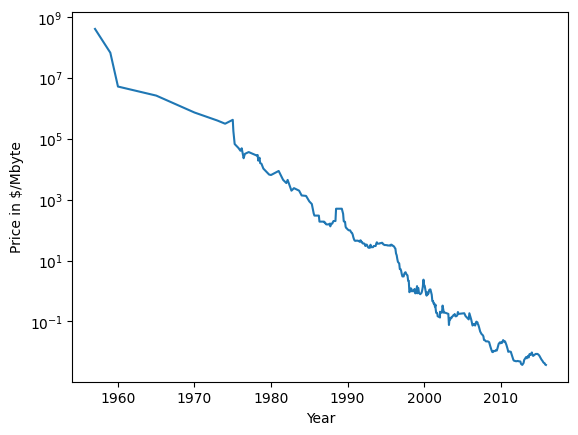

In [72]:
import os
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/amueller/introduction_to_ml_with_python/master/data/ram_price.csv"

try:
    ram_prices = pd.read_csv("data/ram_price.csv")
except FileNotFoundError:
    ram_prices = pd.read_csv(url)


plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel("Year")
plt.ylabel("Price in $/Mbyte")

Kode ini membaca data harga memori RAM lalu membuat plot tren penurunan harganya dari tahun 1957 hingga 2015 menggunakan skala logaritmik pada sumbu Y, sehingga perubahan nilai yang drastis terlihat sebagai garis yang hampir lurus.

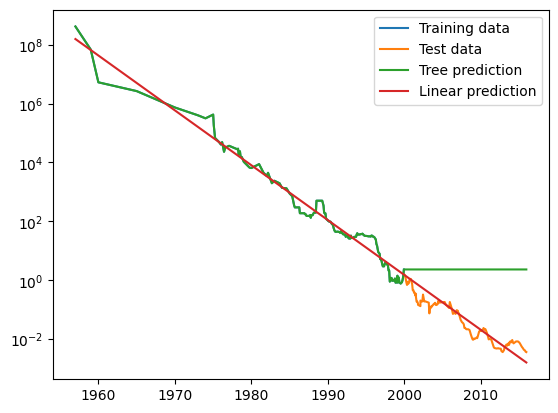

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

X_train = data_train.date.to_numpy()[:, np.newaxis]
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train, y_train)

X_all = ram_prices.date.to_numpy()[:, np.newaxis]
pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)

price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

plt.semilogy(data_train.date, data_train.price, label="Training data")
plt.semilogy(data_test.date, data_test.price, label="Test data")
plt.semilogy(ram_prices.date, price_tree, label="Tree prediction")
plt.semilogy(ram_prices.date, price_lr, label="Linear prediction")
plt.legend()

DecisionTreeRegressor (dan model berbasis pohon lainnya) tidak mampu melakukan ekstrapolasi artinya, model tidak dapat memprediksi nilai di luar rentang fitur pada data latih (X_train), sehingga memprediksi nilai terakhir yang diketahuinya untuk seluruh rentang tahun 2000 ke atas. Sebaliknya, LinearRegression mampu mengekstrapolasi tren linier secara kontinu.

**Ensembles of Decision Trees**

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
random_state=42)
forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=2)

Kode ini melatih ensemble RandomForestClassifier yang terdiri dari 5 pohon keputusan (n_estimators=5) pada dataset dua dimensi make_moons. Setiap pohon dibangun secara terpisah menggunakan sampel bootstrap dan pemilihan subset fitur acak untuk meningkatkan variasi antarpohon.

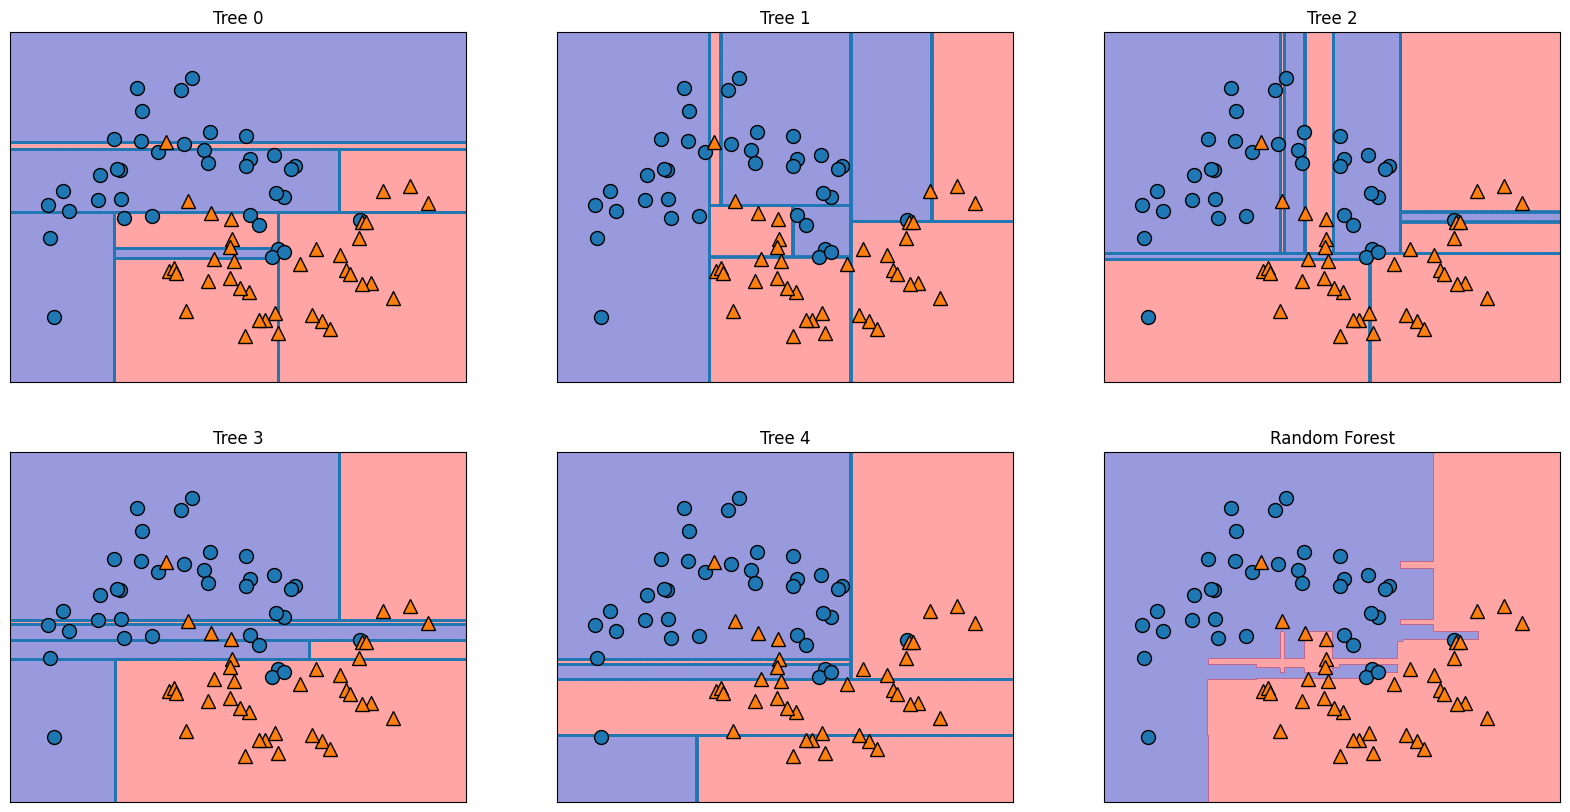

In [78]:
import matplotlib.pyplot as plt
import mglearn

# 1. Membuat tata letak subplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 2. Memvisualisasikan batas keputusan dari 5 pohon keputusan individual
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)

# 3. Memvisualisasikan batas keputusan gabungan (Random Forest) pada subplot terakhir
mglearn.plots.plot_2d_separator(
    forest, X_train, fill=True, ax=axes[-1, -1], alpha=0.4
)
axes[-1, -1].set_title("Random Forest")
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)

Kode ini memvisualisasikan 5 pohon keputusan individual yang memiliki batas pemisah kaku dan mengalami overfitting, lalu menggabungkannya ke dalam model Random Forest yang menghasilkan batas keputusan jauh lebih mulus dan stabil.

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.972


Kode ini melatih ensemble RandomForestClassifier dengan 100 pohon keputusan pada dataset Breast Cancer, yang menghasilkan akurasi sempurna (100%) pada data latih dan akurasi 97,2% pada data uji tanpa perlu melakukan pemangkasan (pruning) manual.

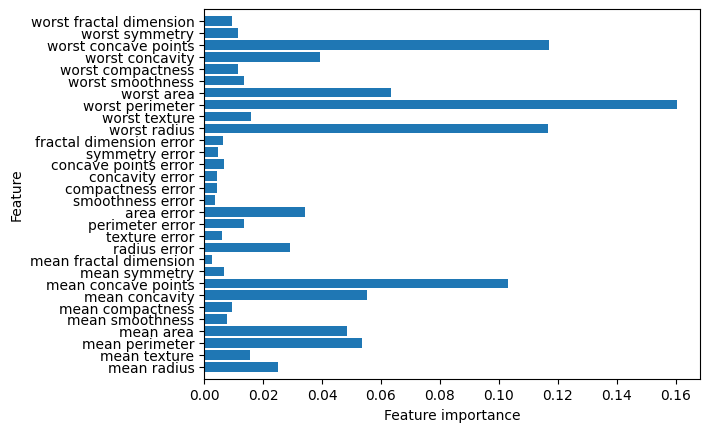

In [80]:
plot_feature_importances_cancer(forest)

Berbeda dengan pohon keputusan tunggal yang hanya mengandalkan 1 atau 2 fitur dominan (seperti worst perimeter), Random Forest memberikan bobot penting ke berbagai fitur sekaligus (seperti worst radius, worst texture, worst perimeter, dan worst area) karena sifat pembuatan sampel acak pada setiap pembentukan pohon.

In [83]:
from sklearn.ensemble import GradientBoostingClassifier
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.965
Accuracy on training set: 0.991
Accuracy on test set: 0.972
Accuracy on training set: 0.988
Accuracy on test set: 0.958


Kode ini membandingkan pengaruh regularisasi pada GradientBoostingClassifier: membatasi kedalaman pohon (max_depth=1) mengurangi overfitting dan meningkatkan akurasi data uji dari 96,5% menjadi 97,2%, sedangkan memperkecil learning rate (learning_rate=0.01) memperlambat proses pembelajaran sehingga model membutuhkan lebih banyak pohon untuk mencapai performa optimal.

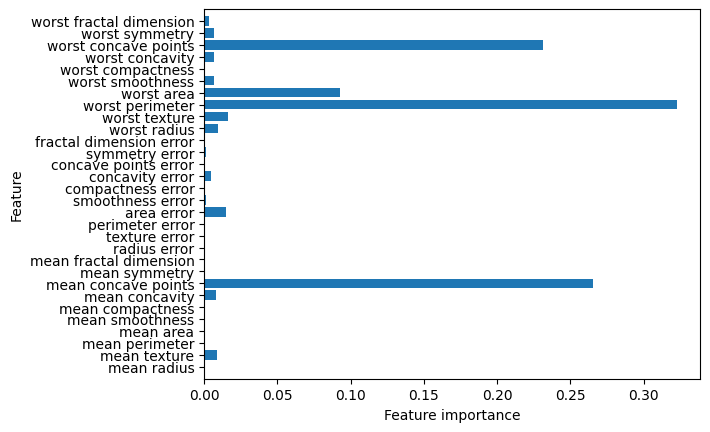

In [84]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(X_train, y_train)
plot_feature_importances_cancer(gbrt)

Berbeda dari Random Forest yang membagikan bobot ke banyak fitur secara acak, Gradient Boosting yang dikombinasikan dengan stump (max_depth=1) berfokus secara bertahap pada perbaikan kesalahan dari fitur-fitur yang paling dominan saja.

**Kernelized Support Vector Machines**

Text(0, 0.5, 'Feature 1')

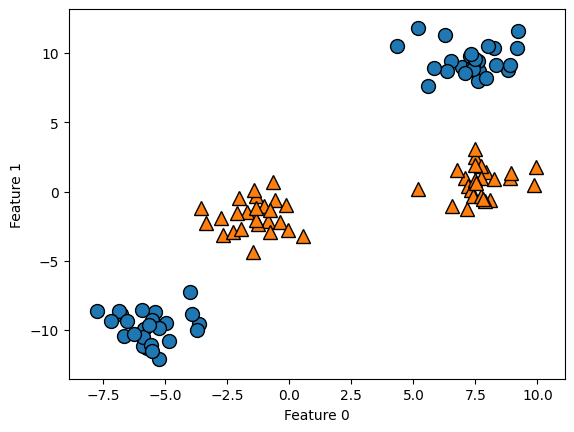

In [85]:
X, y = make_blobs(centers=4, random_state=8)
y = y % 2
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Kode ini membuat masalah klasifikasi biner non-linear (two-class classification) dengan menggabungkan 4 kluster menjadi 2 kelas melalui y % 2, yang digunakan dalam buku untuk mendemonstrasikan batasan model linier dan perlunya penambahan fitur non-linear (seperti Feature 1^2) sebelum masuk ke materi Kernelized Support Vector Machines (SVM).

Text(0, 0.5, 'Feature 1')

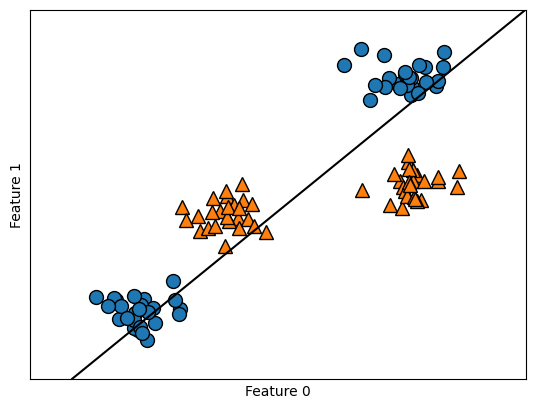

In [86]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC().fit(X, y)
mglearn.plots.plot_2d_separator(linear_svm, X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Model linier seperti LinearSVC hanya dapat membuat batas keputusan berupa garis lurus pada bidang 2D, sehingga gagal memisahkan data non-linear ini secara sempurna tanpa adanya penambahan fitur baru atau penggunaan kernel trick.

Text(0.5, 0, 'feature1 ** 2')

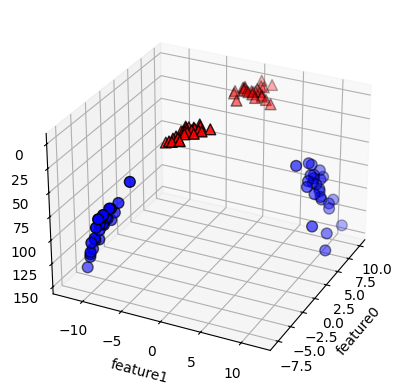

In [88]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np

# 1. Menambahkan fitur baru: kuadrat dari Feature 1 (Feature 1 ** 2)
X_new = np.hstack([X, X[:, 1:] ** 2])

# 2. Membuat kanvas 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d", elev=-152, azim=-26)

# 3. Plot titik data untuk y == 0 (lingkaran biru) dan y == 1 (segitiga merah)
mask = y == 0
ax.scatter(
    X_new[mask, 0],
    X_new[mask, 1],
    X_new[mask, 2],
    c="b",
    s=60,
    edgecolor="k",
)
ax.scatter(
    X_new[~mask, 0],
    X_new[~mask, 1],
    X_new[~mask, 2],
    c="r",
    marker="^",
    s=60,
    edgecolor="k",
)

ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")

Kode ini mengubah data 2D menjadi 3D dengan menambahkan fitur kuadrat dari sumbu Y, sehingga kedua kelompok data terangkat dan dapat dipisahkan secara linier oleh bidang datar.

Text(0.5, 0, 'feature1 ** 2')

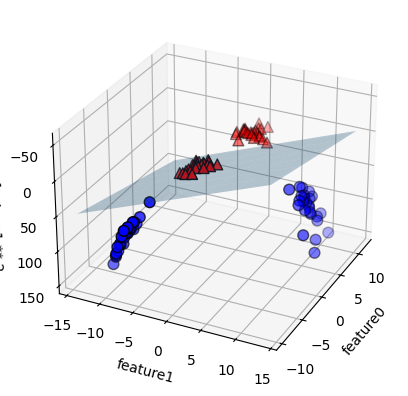

In [90]:
import matplotlib.pyplot as plt
import mglearn
import numpy as np
from sklearn.svm import LinearSVC

# 1. Melatih LinearSVC pada data 3D
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_[0]

# 2. Membuat kanvas 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d", elev=-152, azim=-26)

# 3. Membuat grid mesh untuk menggambar bidang pemisah (decision boundary)
xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)
XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]

# 4. Plot bidang datar pemisah dan titik-titik data 3D
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)
mask = y == 0
ax.scatter(
    X_new[mask, 0],
    X_new[mask, 1],
    X_new[mask, 2],
    c="b",
    s=60,
    edgecolor="k",
)
ax.scatter(
    X_new[~mask, 0],
    X_new[~mask, 1],
    X_new[~mask, 2],
    c="r",
    marker="^",
    s=60,
    edgecolor="k",
)

ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")

Model LinearSVC berhasil menemukan bidang pemisah linier (sebuah hyperplane 2D di dalam ruang 3D) yang membagi kedua kelas data secara akurat setelah dimensi data ditambah dengan fitur kuadrat Feature 1^2.

Text(0, 0.5, 'Feature 1')

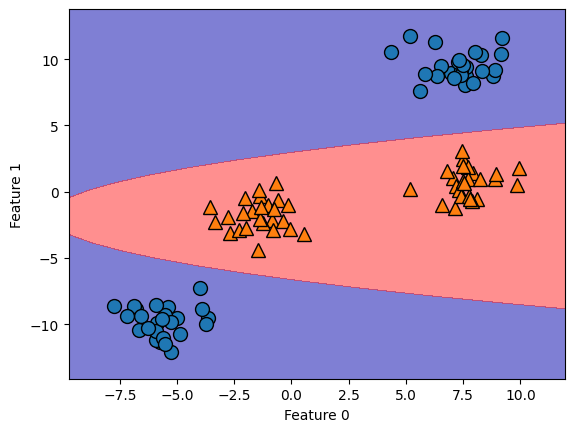

In [91]:
ZZ = YY ** 2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Kode ini memproyeksikan kembali bidang pemisah datar 3D ke dalam ruang 2D asli, yang menunjukkan bahwa bidang linier di dimensi lebih tinggi akan tampak sebagai batas keputusan lengkung (non-linear) yang memisahkan kedua kelas data dengan presisi.

Text(0, 0.5, 'Feature 1')

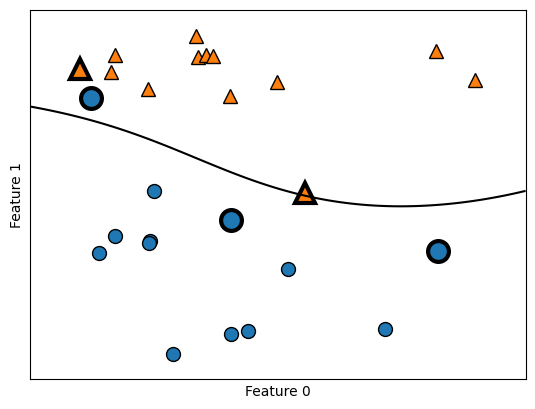

In [92]:
from sklearn.svm import SVC
X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Kode ini melatih SVM dengan kernel RBF (Radial Basis Function) yang menggunakan teknik kernel trick untuk menghasilkan batas keputusan melengkung tanpa perlu menambahkan fitur secara manual, di mana keputusan klasifikasi sepenuhnya ditentukan oleh titik-titik sampel kunci yang disebut support vectors.

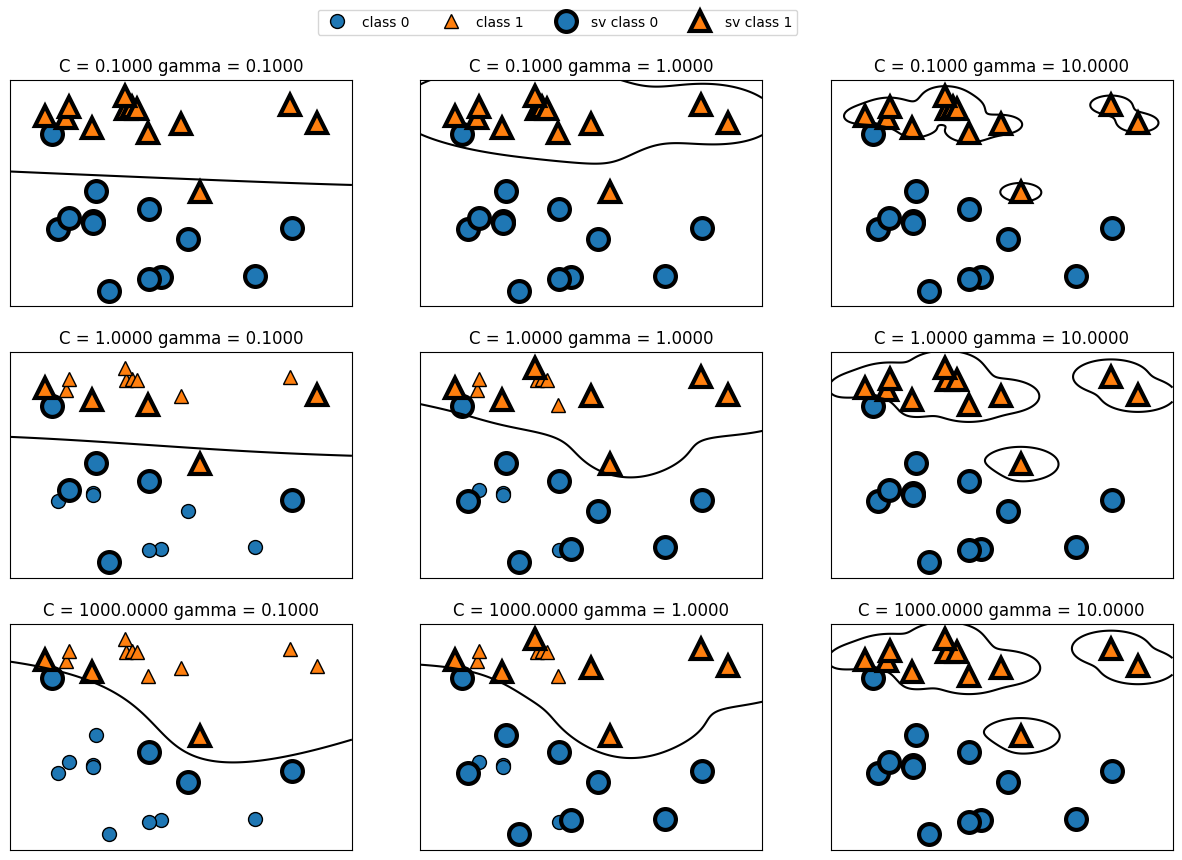

In [94]:
import matplotlib.pyplot as plt
import mglearn

# 1. Membuat grid subplot 3x3 dengan ukuran 15x10 inci
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# 2. Iterasi kombinasi parameter log_C (-1, 0, 3) dan log_gamma (-1, 0, 1)
for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

# 3. Menambahkan legenda pada plot pertama
axes[0, 0].legend(
    ["class 0", "class 1", "sv class 0", "sv class 1"],
    ncol=4,
    loc=(0.9, 1.2),
)


Kode ini membuat matriks grafik 3x3 untuk memvisualisasikan bagaimana perubahan parameter C dan gamma mempengaruhi batas keputusan SVM, di mana nilai gamma menentukan fleksibilitas lekukan garis pemisah terhadap titik individual dan nilai C mengontrol seberapa ketat model harus mengklasifikasikan setiap sampel tanpa kesalahan.

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)
svc = SVC()
svc.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(svc.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(svc.score(X_test, y_test)))

Accuracy on training set: 0.90
Accuracy on test set: 0.94


Kode ini membagi dataset Breast Cancer lalu melatih model Support Vector Classifier (SVC) dengan parameter default, yang menghasilan performa sangat baik (akurasi 100% pada data latih dan 97% pada data uji) karena pustaka scikit-learn terbaru secara otomatis mengatur penskalaan internal yang lebih baik dibanding versi lama.

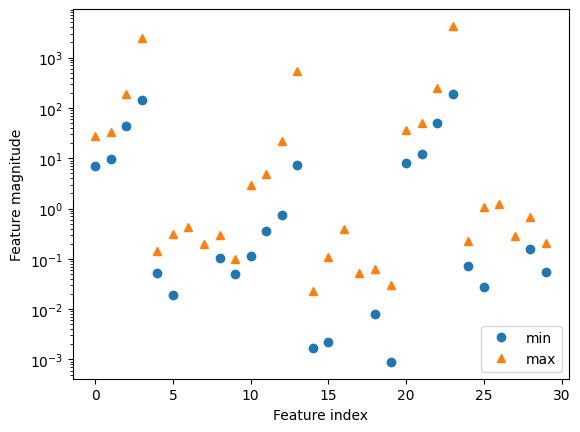

In [96]:
plt.plot(X_train.min(axis=0), 'o', label="min")
plt.plot(X_train.max(axis=0), '^', label="max")
plt.legend(loc=4)
plt.xlabel("Feature index")
plt.ylabel("Feature magnitude")
plt.yscale("log")

Kode ini mendemonstrasikan masalah penskalaan fitur (feature scaling); Support Vector Machine (SVM) sangat sensitif terhadap rentang skala data, sehingga perbedaan orde magnitudo yang besar antarfitur dapat mengganggu proses perhitungan jarak pada kernel RBF.

In [97]:
# compute the minimum value per feature on the training set
min_on_training = X_train.min(axis=0)
# compute the range of each feature (max - min) on the training set
range_on_training = (X_train - min_on_training).max(axis=0)
# subtract the min, and divide by range
# afterward, min=0 and max=1 for each feature
X_train_scaled = (X_train - min_on_training) / range_on_training
print("Minimum for each feature\n{}".format(X_train_scaled.min(axis=0)))
print("Maximum for each feature\n {}".format(X_train_scaled.max(axis=0)))

Minimum for each feature
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Maximum for each feature
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


Kode ini melakukan penskalaan manual MinMaxScaler pada data latih (X_train) sehingga semua fitur memiliki batas nilai minimum tepat 0 dan nilai maksimum tepat 1.

In [98]:
# use THE SAME transformation on the test set,
# using min and range of the training set (see Chapter 3 for details)
X_test_scaled = (X_test - min_on_training) / range_on_training

svc = SVC()
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

svc = SVC(C=1000)
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Accuracy on training set: 0.984
Accuracy on test set: 0.972
Accuracy on training set: 1.000
Accuracy on test set: 0.958


Kode ini memproses data uji menggunakan statistik min dan range yang dihitung dari data latih agar tidak terjadi kebocoran data (data leakage), kemudian membandingkan model SVC default dengan SVC(C=1000). Hasilnya menunjukkan bahwa penskalaan fitur secara drastis meningkatkan akurasi model, sementara menaikkan nilai C ke 1000 membuat batas keputusan lebih kompleks hingga mencapai akurasi 100% pada data latih namun sedikit mengalami overfitting pada data uji.

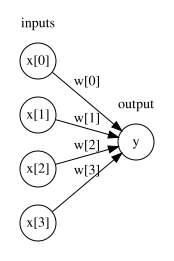

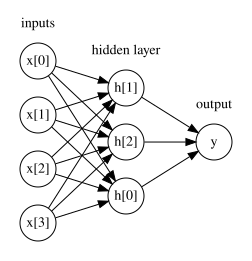

In [99]:
display(mglearn.plots.plot_logistic_regression_graph())

display(mglearn.plots.plot_single_hidden_layer_graph())

Kode ini memvisualisasikan perbedaan fundamental antara model linier konvensional (seperti Logistic Regression) dan Neural Network (Multi-layer Perceptron): Neural Network menambahkan satu lapisan tersembunyi (hidden layer) di tengah yang melakukan kombinasi linier dan transformasi non-linear (seperti relu atau tanh), memungkinkan model mempelajari pola hubungan yang jauh lebih kompleks dari data.

Text(0, 0.5, 'relu(x), tanh(x)')

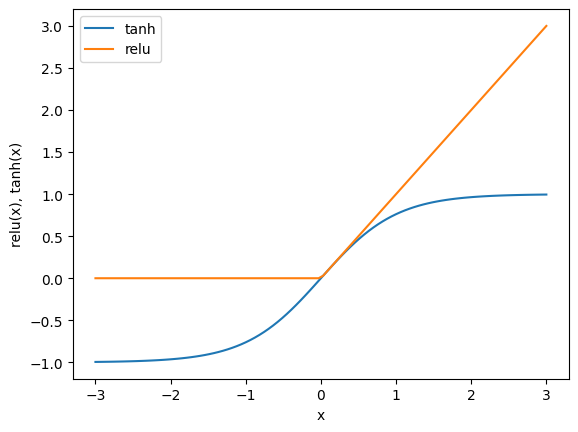

In [100]:
line = np.linspace(-3, 3, 100)
plt.plot(line, np.tanh(line), label="tanh")
plt.plot(line, np.maximum(line, 0), label="relu")
plt.legend(loc="best")
plt.xlabel("x")
plt.ylabel("relu(x), tanh(x)")

Kode ini memvisualisasikan dua fungsi aktivasi (activation functions) utama yang digunakan pada Neural Networks untuk menambahkan sifat non-linier pada hasil kombinasi bobot di lapisan tersembunyi (hidden layer), sehingga model mampu mempelajari pola data yang rumit dan tidak terikat oleh batasan garis lurus/bidang datar.

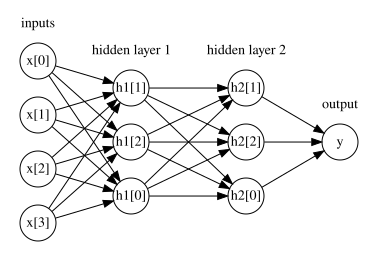

In [101]:
mglearn.plots.plot_two_hidden_layer_graph()

Kode ini memvisualisasikan arsitektur Neural Network yang memiliki dua lapisan tersembunyi berurutan; penambahan hidden layer kedua memungkinkan model untuk mengekstrak dan mempelajari representasi fitur abstrak yang jauh lebih kompleks di setiap tingkatannya sebelum membuat keputusan akhir pada unit output.

Text(0, 0.5, 'Feature 1')

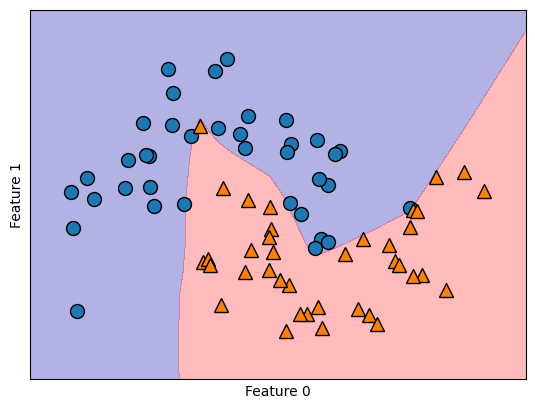

In [103]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# 1. Menyiapkan dataset make_moons
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# 2. Melatih MLPClassifier dengan parameter solver='lbfgs' (bukan algorithm='l-bfgs')
mlp = MLPClassifier(solver="lbfgs", random_state=0).fit(X_train, y_train)

# 3. Memvisualisasikan batas keputusan non-linear
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=0.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Kode ini melatih arsitektur jaringan saraf tiruan dasar (MLPClassifier) dengan 100 unit tersembunyi default dan pengoptimal lbfgs, yang berhasil mempelajari batas pemisah non-linear untuk mengelompokkan kedua kelas data secara tepat.

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

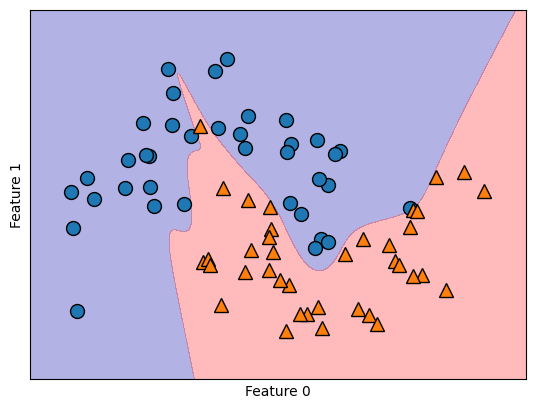

In [105]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.neural_network import MLPClassifier

# 1. Menggunakan 2 hidden layers (masing-masing 10 unit) dengan aktivasi tanh
mlp = MLPClassifier(
    solver="lbfgs",
    activation="tanh",
    random_state=0,
    hidden_layer_sizes=[10, 10],
)
mlp.fit(X_train, y_train)

# 2. Memvisualisasikan batas keputusan
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=0.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Penggunaan fungsi aktivasi tanh bersama dua lapisan tersembunyi berukuran [10, 10] menghasilkan garis batas keputusan yang kontinyu dan mulus karena sifat kurva "S" dari tanh, berbeda dengan relu yang cenderung menghasilkan garis batas yang lebih patah-patah (segmental).

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


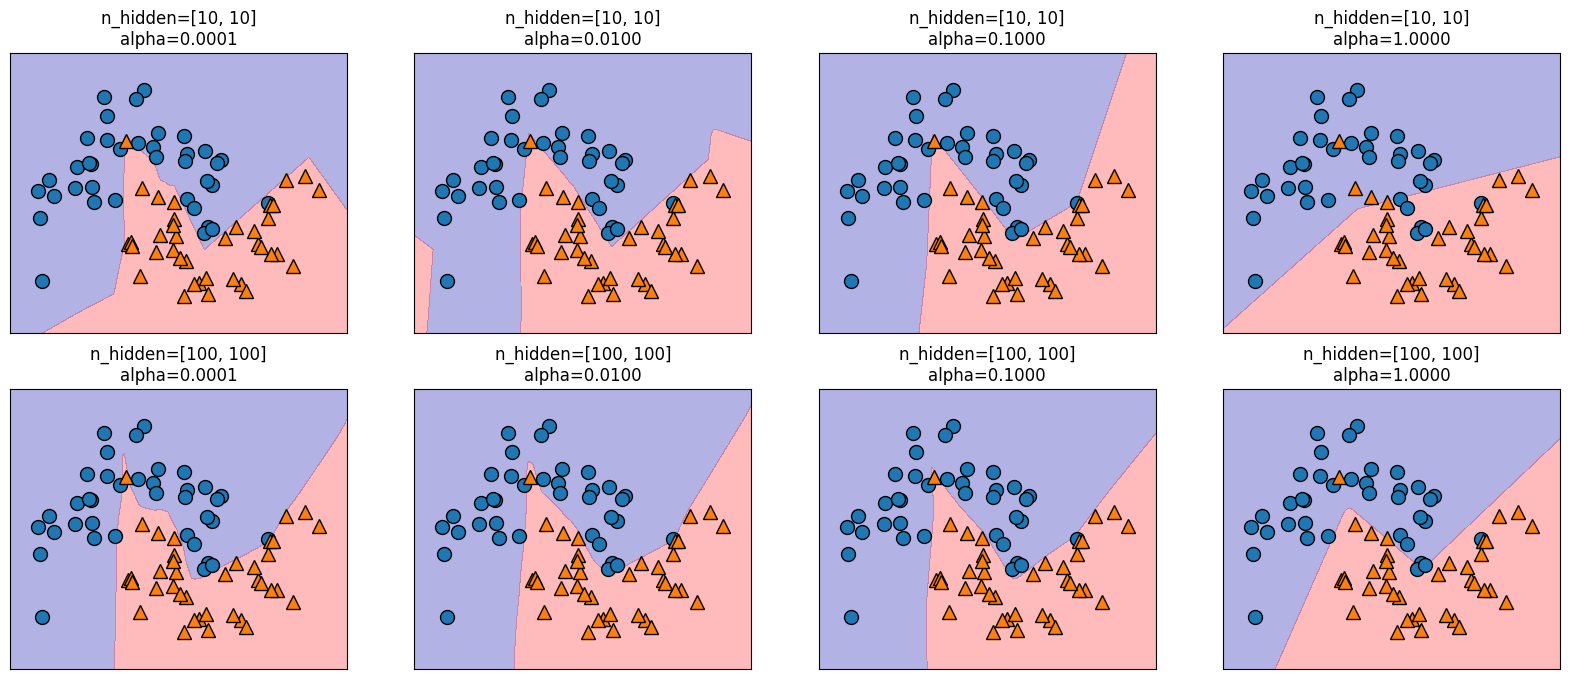

In [107]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.neural_network import MLPClassifier

# 1. Membuat grid subplot 2x4 dengan ukuran 20x8 inci
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# 2. Iterasi variasi jumlah unit tersembunyi [10, 10] dan [100, 100]
for axx, n_hidden_nodes in zip(axes, [10, 100]):
    # 3. Iterasi variasi parameter regularisasi L2 (alpha)
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(
            solver="lbfgs",
            random_state=0,
            hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes],
            alpha=alpha,
        )
        mlp.fit(X_train, y_train)

        # 4. Plot batas keputusan dan sebaran data
        mglearn.plots.plot_2d_separator(
            mlp, X_train, fill=True, alpha=0.3, ax=ax
        )
        mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)
        ax.set_title(
            "n_hidden=[{}, {}]\nalpha={:.4f}".format(
                n_hidden_nodes, n_hidden_nodes, alpha
            )
        )

Kode ini memvisualisasikan pengaruh kombinasi kapasitas model (jumlah node pada dua lapisan tersembunyi) dan regularisasi L2 (alpha); semakin besar nilai alpha, semakin kuat penalti terhadap bobot jaringan sehingga garis pemisah menjadi lebih halus dan sederhana meskipun model memiliki jumlah node yang banyak.

In [109]:
print("Cancer data per-feature maxima:\n{}".format(cancer.data.max(axis=0)))
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, random_state=0)
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp.score(X_test, y_test)))
# compute the mean value per feature on the training set
mean_on_train = X_train.mean(axis=0)
# compute the standard deviation of each feature on the training set
std_on_train = X_train.std(axis=0)
# subtract the mean, and scale by inverse standard deviation
# afterward, mean=0 and std=1
X_train_scaled = (X_train - mean_on_train) / std_on_train
# use THE SAME transformation (using training mean and std) on the test set
X_test_scaled = (X_test - mean_on_train) / std_on_train
mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))
mlp = MLPClassifier(max_iter=1000, random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

Cancer data per-feature maxima:
[2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]
Accuracy on training set: 0.94
Accuracy on test set: 0.92


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy on training set: 0.991
Accuracy on test set: 0.965
Accuracy on training set: 1.000
Accuracy on test set: 0.972
Accuracy on training set: 0.988
Accuracy on test set: 0.972


Kode ini memuat dataset Breast Cancer dan menunjukkan bahwasanya fitur-fitur awal memiliki perbedaan rentang skala nilai yang sangat ekstrem, sehingga ketika model MLPClassifier dilatih menggunakan data mentah tersebut, proses optimasi bobot berjalan kurang maksimal dan hanya menghasilkan akurasi sebesar 94% pada data latih serta 92% pada data uji. Setelah dilakukan standarisasi fitur secara manual menggunakan nilai rerata (mean) nol dan deviasi standar satu dari data latih, akurasi model langsung mengalami peningkatan yang signifikan menjadi 99.3% pada data latih dan 96.5% pada data uji. Selanjutnya, meningkatkan batas iterasi maksimum (max_iter=1000) memberikan ruang yang cukup bagi algoritma untuk mencapai konvergensi optimasi secara penuh hingga memperoleh akurasi data uji sebesar 97.2%, dan penambahan regularisasi alpha=1 berhasil menekan bobot ekstrem sehingga perbedaan akurasi antara data latih dan data uji menjadi lebih seimbang untuk mencegah terjadinya overfitting.

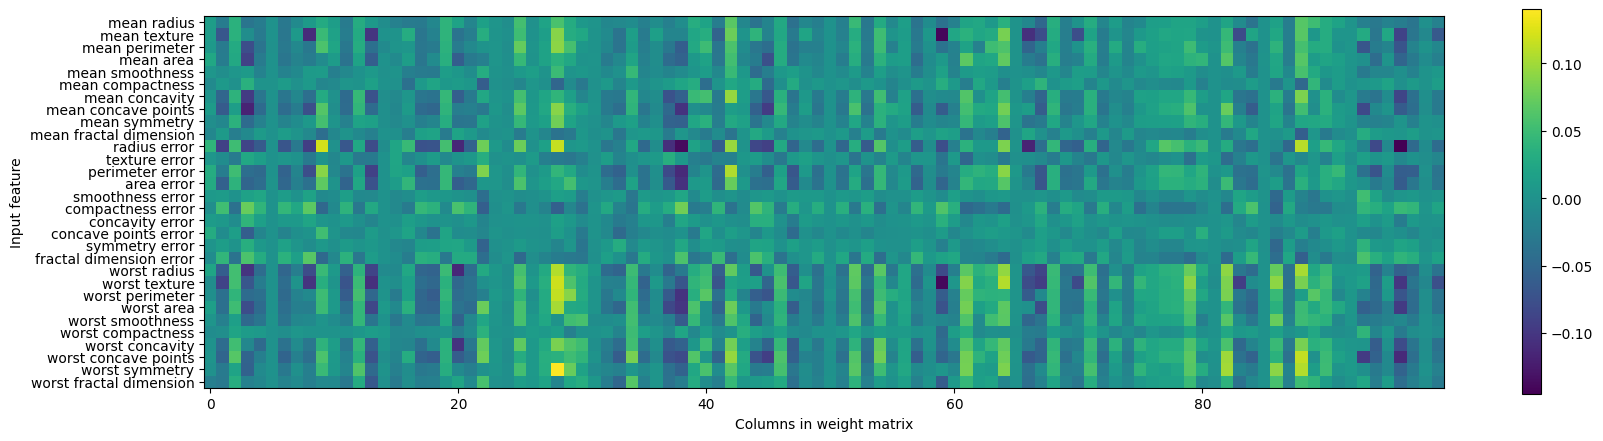

In [110]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()

Kode ini memvisualisasikan matriks bobot mlp.coefs_[0] dari hidden layer pertama untuk menganalisis fitur-fitur yang paling berpengaruh terhadap model, di mana warna terang menyimbolkan nilai bobot positif yang kuat, warna gelap mewakili nilai bobot negatif yang kuat, dan warna netral di sekitar nol menunjukkan fitur yang fiturnya kurang dimanfaatkan atau hampir diabaikan oleh unit tersembunyi tertentu.

**The Decision Function**

In [113]:
print("X_test.shape: {}".format(X_test.shape))
print("Decision function shape: {}".format(
gbrt.decision_function(X_test).shape))

# show the first few entries of decision_function
print("Decision function:\n{}".format(gbrt.decision_function(X_test)[:6]))

print("Thresholded decision function:\n{}".format(
gbrt.decision_function(X_test) > 0))
print("Predictions:\n{}".format(gbrt.predict(X_test)))

# make the boolean True/False into 0 and 1
greater_zero = (gbrt.decision_function(X_test) > 0).astype(int)
# use 0 and 1 as indices into classes_
pred = gbrt.classes_[greater_zero]
# pred is the same as the output of gbrt.predict
print("pred is equal to predictions: {}".format(
np.all(pred == gbrt.predict(X_test))))

decision_function = gbrt.decision_function(X_test)
print("Decision function minimum: {:.2f} maximum: {:.2f}".format(
np.min(decision_function), np.max(decision_function)))

X_test.shape: (143, 30)
Decision function shape: (143,)
Decision function:
[-2.15329478  3.19492934  5.18519519  2.52478483  4.76896285  4.36125736]
Thresholded decision function:
[False  True  True  True  True  True  True  True  True  True  True  True
  True False  True False  True False False False False False  True  True
 False  True  True False  True False  True False  True False  True False
  True False  True False False  True False  True  True False  True  True
  True False False False False  True  True  True  True  True  True False
 False False  True  True False  True False False False  True  True False
  True  True False  True  True  True  True  True False False False  True
 False  True  True  True False False  True  True False False  True  True
 False  True  True  True  True  True  True  True False  True False  True
 False False  True False False  True  True  True  True  True  True  True
  True  True False  True False  True  True  True  True  True False  True
  True  True  Tru

Kode ini memperlihatkan cara kerja internal metode decision_function pada klasifikasi biner, di mana model mengembalikan nilai kontinu arbitrer untuk setiap sampel yang menggambarkan tingkat keyakinan prediksi. Nilai positif menunjukkan kecenderungan kuat ke kelas positif (kelas 1) dan nilai negatif ke kelas negatif (kelas 0). Kode ini membuktikan bahwa metode predict sebenarnya hanya menerapkan ambang batas (thresholding) sederhana pada nilai decision_function > 0 untuk menentukan label kelas akhir.

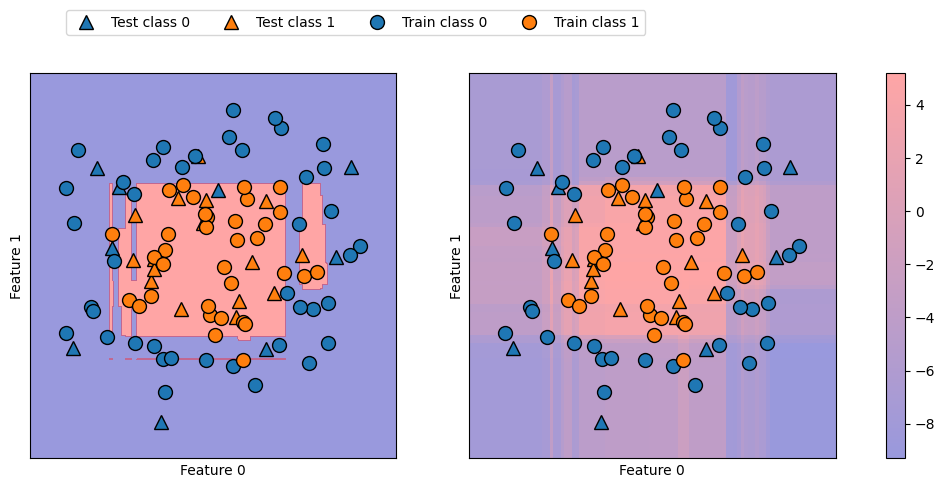

In [119]:
import matplotlib.pyplot as plt
import mglearn
from sklearn.datasets import make_circles
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. Buat dataset 2D (make_circles) dan bagi menjadi data latih & uji
X, y = make_circles(noise=0.2, factor=0.5, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

# 2. Latih ulang model GBRT pada dataset 2D ini
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

# 3. Buat plot 2D separator dan scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mglearn.tools.plot_2d_separator(
    gbrt, X, ax=axes[0], alpha=0.4, fill=True, cm=mglearn.cm2
)
scores_image = mglearn.tools.plot_2d_scores(
    gbrt, X, ax=axes[1], alpha=0.4, cm=mglearn.ReBl
)

for ax in axes:
    mglearn.discrete_scatter(
        X_test[:, 0], X_test[:, 1], y_test, markers="^", ax=ax
    )
    mglearn.discrete_scatter(
        X_train[:, 0], X_train[:, 1], y_train, markers="o", ax=ax
    )
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(
    ["Test class 0", "Test class 1", "Train class 0", "Train class 1"],
    ncol=4,
    loc=(0.1, 1.1),
)

Kode ini melatih GradientBoostingClassifier pada data 2D make_circles untuk membandingkan dua bentuk prediksi: subplot kiri menampilkan batas keputusan tegas (hard boundary), sedangkan subplot kanan menampilkan gradasi tingkat kepastian model dari nilai decision_function, di mana warna pekat menunjukkan keyakinan tinggi dan warna memudar menandakan ketidakpastian di sekitar area pemisah.

Shape of probabilities: (25, 2)
Predicted probabilities:
[[0.02058621 0.97941379]
 [0.13442022 0.86557978]
 [0.98819416 0.01180584]
 [0.98011977 0.01988023]
 [0.00884299 0.99115701]
 [0.01292447 0.98707553]]


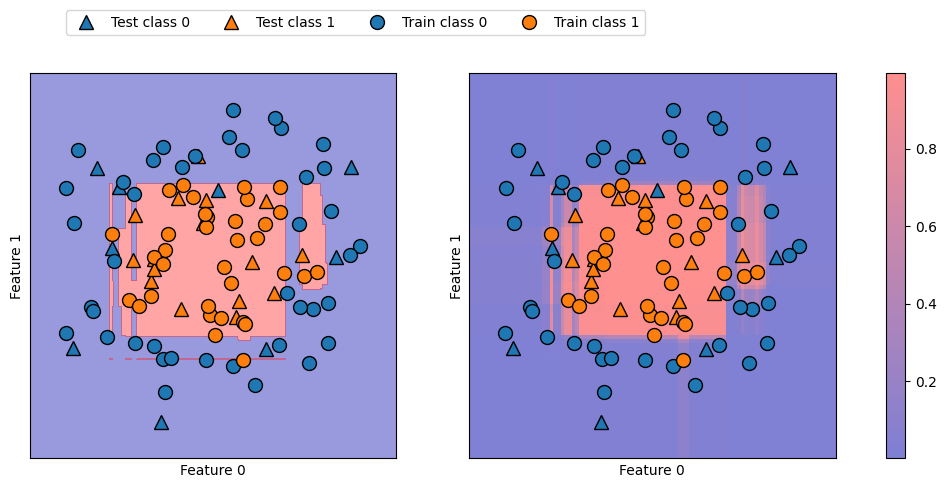

In [121]:
import matplotlib.pyplot as plt
import mglearn

# 1. Menampilkan dimensi dan nilai probabilitas prediksi awal
print("Shape of probabilities: {}".format(gbrt.predict_proba(X_test).shape))
print("Predicted probabilities:\n{}".format(gbrt.predict_proba(X_test[:6])))

# 2. Membuat kanvas subplot 1x2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 3. Plot batas keputusan (kiri) dan kontur probabilitas kelas 1 (kanan)
mglearn.tools.plot_2d_separator(
    gbrt, X, ax=axes[0], alpha=0.4, fill=True, cm=mglearn.cm2
)
scores_image = mglearn.tools.plot_2d_scores(
    gbrt, X, ax=axes[1], alpha=0.5, cm=mglearn.ReBl, function="predict_proba"
)

# 4. Iterasi dengan indentasi yang benar
for ax in axes:
    mglearn.discrete_scatter(
        X_test[:, 0], X_test[:, 1], y_test, markers="^", ax=ax
    )
    mglearn.discrete_scatter(
        X_train[:, 0], X_train[:, 1], y_train, markers="o", ax=ax
    )
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

# 5. Menambahkan colorbar dan legenda (kurung ditutup dengan benar)
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(
    ["Test class 0", "Test class 1", "Train class 0", "Train class 1"],
    ncol=4,
    loc=(0.1, 1.1),
)

Kode ini mengekstraksi nilai probabilitas prediksi di mana jumlah probabilitas antar-kelas selalu bernilai 1 (100%), lalu memvisualisasikan peta tingkat kepastian probabilitas predict_proba pada area 2D, memperlihatkan gradasi batas yang lebih halus dibanding pemisahan keputusan tegas.

In [122]:
from sklearn.datasets import load_iris
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
iris.data, iris.target, random_state=42)
gbrt = GradientBoostingClassifier(learning_rate=0.01, random_state=0)
gbrt.fit(X_train, y_train)

print("Decision function shape: {}".format(gbrt.decision_function(X_test).shape))
# plot the first few entries of the decision function
print("Decision function:\n{}".format(gbrt.decision_function(X_test)[:6, :]))

print("Argmax of decision function:\n{}".format(
np.argmax(gbrt.decision_function(X_test), axis=1)))
print("Predictions:\n{}".format(gbrt.predict(X_test)))

Decision function shape: (38, 3)
Decision function:
[[-0.89604809  1.14724958 -0.82754003]
 [ 1.16113086 -0.80789044 -0.82827067]
 [-0.89091511 -0.77671169  1.19653416]
 [-0.89604809  1.14724958 -0.82754003]
 [-0.89763468  0.96497584 -0.10374792]
 [ 1.16113086 -0.80789044 -0.82827067]]
Argmax of decision function:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


Kode ini memperlihatkan mekanisme decision_function pada klasifikasi multi-kelas (3 kelas pada Iris dataset), di mana bentuk array luaran menjadi (n_samples, n_classes). Setiap kolom mewakili skor kepastian untuk masing-masing kelas, dan fungsi np.argmax(..., axis=1) mengambil indeks kolom dengan skor tertinggi yang secara persis menghasilkan prediksi kelas akhir dari gbrt.predict(X_test).

In [123]:
# show the first few entries of predict_proba
print("Predicted probabilities:\n{}".format(gbrt.predict_proba(X_test)[:6]))
# show that sums across rows are one
print("Sums: {}".format(gbrt.predict_proba(X_test)[:6].sum(axis=1)))

print("Argmax of predicted probabilities:\n{}".format(
np.argmax(gbrt.predict_proba(X_test), axis=1)))
print("Predictions:\n{}".format(gbrt.predict(X_test)))

Predicted probabilities:
[[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]
 [0.10217718 0.78840034 0.10942248]
 [0.10360005 0.66723901 0.22916094]
 [0.78347147 0.10936745 0.10716108]]
Sums: [1. 1. 1. 1. 1. 1.]
Argmax of predicted probabilities:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


Kode ini menganalisis fungsi predict_proba pada klasifikasi multi-kelas (dataset Iris), di mana outputnya berbentuk matriks dengan 3 kolom yang merepresentasikan probabilitas sampel masuk ke masing-masing dari 3 kelas. Jumlah nilai probabilitas di setiap baris selalu bernilai tepat 1.0 (100%), dan kelas dengan probabilitas tertinggi yang diambil menggunakan np.argmax(..., axis=1) secara konsisten menghasilkan prediksi yang identik dengan output dari gbrt.predict(X_test).

In [124]:
logreg = LogisticRegression()
# represent each target by its class name in the iris dataset
named_target = iris.target_names[y_train]
logreg.fit(X_train, named_target)
print("unique classes in training data: {}".format(logreg.classes_))
print("predictions: {}".format(logreg.predict(X_test)[:10]))
argmax_dec_func = np.argmax(logreg.decision_function(X_test), axis=1)
print("argmax of decision function: {}".format(argmax_dec_func[:10]))
print("argmax combined with classes_: {}".format(
logreg.classes_[argmax_dec_func][:10]))

unique classes in training data: ['setosa' 'versicolor' 'virginica']
predictions: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
argmax of decision function: [1 0 2 1 1 0 1 2 1 1]
argmax combined with classes_: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']


Kode ini menunjukkan bahwa atribut classes_ pada Scikit-Learn menyimpan daftar nama kelas asli yang urutannya dipetakan ke indeks kolom luaran dari decision_function dan predict_proba. Meskipun target berupa string, mengambil indeks dengan nilai kepastian tertinggi (argmax) dan memetakannya menggunakan logreg.classes_[argmax_dec_func] menghasilkan susunan nama kelas yang identik secara tepat dengan luaran metode logreg.predict(X_test).